In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np 
import geopandas as gpd 
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.patches import Wedge
import matplotlib.colors as mcolors
from matplotlib.patches import ConnectionPatch
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
nonval_df = pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_non_validated_v8.xlsx")
validated_df = pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_validated_v8.xlsx")

In [3]:
nonval_df.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'where_sequenced', 'other_k13_mutations',
       'Frequency', 'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [4]:
validated_df["pmid"].nunique()

126

In [5]:
nonval_df.groupby("country")["pmid"].nunique()

country
DRC            15
Eritrea         5
Ethiopia       17
Kenya          27
Rwanda         12
Somalia         2
South Sudan     1
Sudan           6
Tanzania       20
Uganda         29
Zanzibar        2
Name: pmid, dtype: int64

In [6]:
validated_df.groupby("country")["pmid"].nunique()

country
Burundi         1
DRC            16
Eritrea         5
Ethiopia       20
Kenya          29
Rwanda         13
Somalia         3
South Sudan     1
Sudan           6
Tanzania       22
Uganda         31
Zanzibar        2
Name: pmid, dtype: int64

In [7]:
validated_df.drop(columns="other_k13_mutations", inplace=True)

In [8]:
df_combined = pd.concat([nonval_df, validated_df], ignore_index=True, sort=False)


In [9]:
df_combined.sort_values(by="country")

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,k13_validated_mutations,type_of_mutation,mutation_frequency_(%)
2920,34279219,2021,"2015, 2016, 2019",Burundi,missing,missing,missing,missing,389,AS+AQ,...,NaN,none,open,NaN,NaN,-,-,-,-,0
3339,38377612,2024,2022,DRC,South Kivu,Bukavu,missing,missing,292,AL/ASAQ,...,NaN,raw count,closed,1,0.4,-2.5056,28.8595,C469Y,non-synonymous,1(0.4)
2005,40021306,2025,2021-2023,DRC,Kinshasa,"Binza, Maluku",All,years,6795,missing,...,2(0.2),raw count,open,2.0,0.2,-4.46139,16.07861,NaN,NaN,NaN
2276,34491220,2021,2017-2018,DRC,Kongo Central,kimpese,"""6-59""",months,577,AS+AQ,...,NaN,none,open,NaN,NaN,-5.5618,14.4288,-,-,0
140,25180240,2014,2005-2006,DRC,Kinshasha,Kinshasa,missing,missing,35,AS+AQ,...,1.83,percentage,open,NaN,1.83,-4.375,15.97,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1821,40802860,2025,2022-2024,Zanzibar,missing,Mjini,all years,years,1433,-,...,36/426,raw count,open,36.0,8.45,-6.168,39.2097,NaN,NaN,NaN
1822,40802860,2025,2022-2024,Zanzibar,missing,Mjini,all years,years,1433,-,...,1/477,raw count,open,1.0,0.21,-6.168,39.2097,NaN,NaN,NaN
1823,40802860,2025,2022-2024,Zanzibar,missing,Mjini,all years,years,1433,-,...,92/477,raw count,open,92.0,19.29,-6.168,39.2097,NaN,NaN,NaN
1825,40802860,2025,2022-2024,Zanzibar,missing,Mjini,all years,years,1433,-,...,1/409,raw count,open,1.0,0.24,-6.168,39.2097,NaN,NaN,NaN


In [10]:
df_combined.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'where_sequenced', 'other_k13_mutations',
       'Frequency', 'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude',
       'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)'],
      dtype='object')

In [11]:
df_combined.drop(columns=['participants_age', 'participants_age_unit','where_sequenced','participants_age_unit', 'first_line_act',
       'genotyping_assay', 'study_population'], inplace=True)

In [12]:
df_combined

,pmid,year_pub,year_sample,country,region/province,town,sample_size,samples_genotyped,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,k13_validated_mutations,type_of_mutation,mutation_frequency_(%)
0,34551228,2021,2015,Uganda,Northern Uganda,Gulu,77,77,C532S,2 (2.6),raw counts,open,2.0,2.6,2.85604,32.43001,NaN,NaN,NaN
1,34551228,2021,2015,Uganda,Northern Uganda,Gulu,77,77,V661I,1 (1.3),raw counts,open,1.0,1.3,2.85604,32.43001,NaN,NaN,NaN
2,34551228,2021,2016,Uganda,Northern Uganda,Gulu,94,94,G595C,1 (1.1),raw counts,open,1.0,1.1,2.85604,32.43001,NaN,NaN,NaN
3,34551228,2021,2018,Uganda,Northern Uganda,Gulu,67,67,A578S,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,NaN,NaN,NaN
4,34551228,2021,2018,Uganda,Northern Uganda,Gulu,67,67,S695T,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3335,40681807,2025,2023,Ethiopia,Amhara,Woreta,10,10,NaN,NaN,percentage,open,0,0,11.92367,37.69643,P574L,non-synonymous,0
3336,40681807,2025,2023,Ethiopia,Amhara,Woreta,10,10,NaN,NaN,percentage,open,12,10,11.92367,37.69643,R622I,non-synonymous,10
3337,40681807,2025,2023,Ethiopia,Amhara,Woreta,10,10,NaN,NaN,percentage,open,0,0,11.92367,37.69643,A675V,non-synonymous,0
3338,26875763,2016,2013-2014,Eritrea,"Gash Barka, Debub","Barentu, Agordat, Mdefera",200,180,NaN,NaN,none,closed,0,0,15.10567,37.58888,-,-,0


In [13]:
df_combined.groupby("country")["pmid"].nunique()

country
Burundi         1
DRC            16
Eritrea         6
Ethiopia       23
Kenya          30
Rwanda         14
Somalia         3
South Sudan     1
Sudan           6
Tanzania       23
Uganda         32
Zanzibar        2
Name: pmid, dtype: int64

In [14]:
df_combined[df_combined["country"]=="Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412',
       '10.12688/Wellcomeopenres.17656.1', '28535801', '39425178',
       '31591113', '25367300', '27001814', 40739505, 41184373, 41420179,
       '10.2139/SSRN.4617870', '10.12688/wellcomeopenres.17656.1',
       39819451], dtype=object)

In [15]:
df_combined["pmid"].describe()

count         3340
unique         132
top       37611122
freq           690
Name: pmid, dtype: object

In [16]:
df_combined.groupby("country")["pmid"].nunique

<bound method SeriesGroupBy.nunique of <pandas.core.groupby.generic.SeriesGroupBy object at 0x72539122d940>>

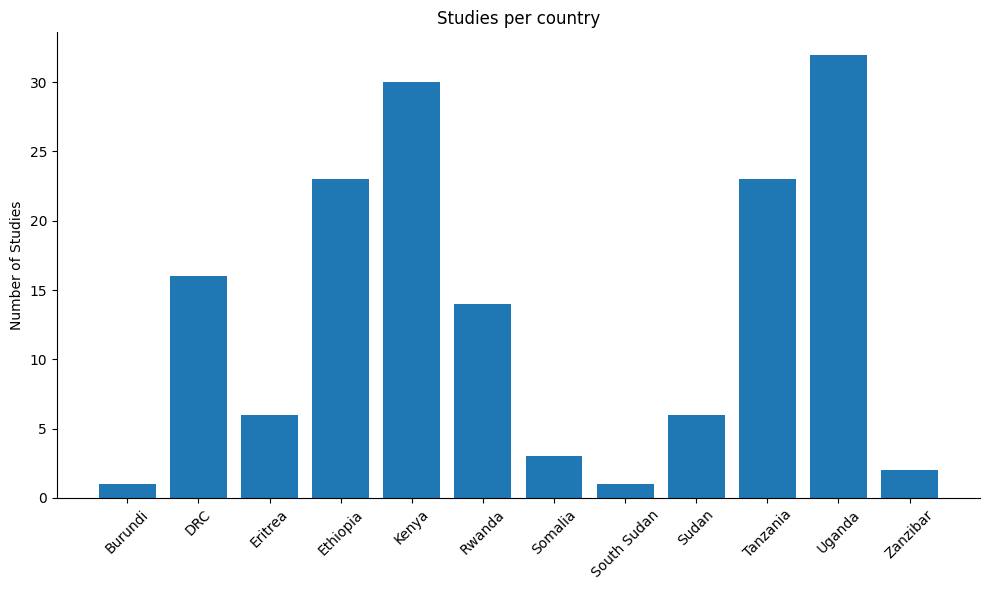

In [17]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country = df_combined.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
validated_df["sample_size"]

0        77
1        77
2        94
3        94
4       101
       ... 
1319     10
1320     10
1321     10
1322    200
1323    292
Name: sample_size, Length: 1324, dtype: object

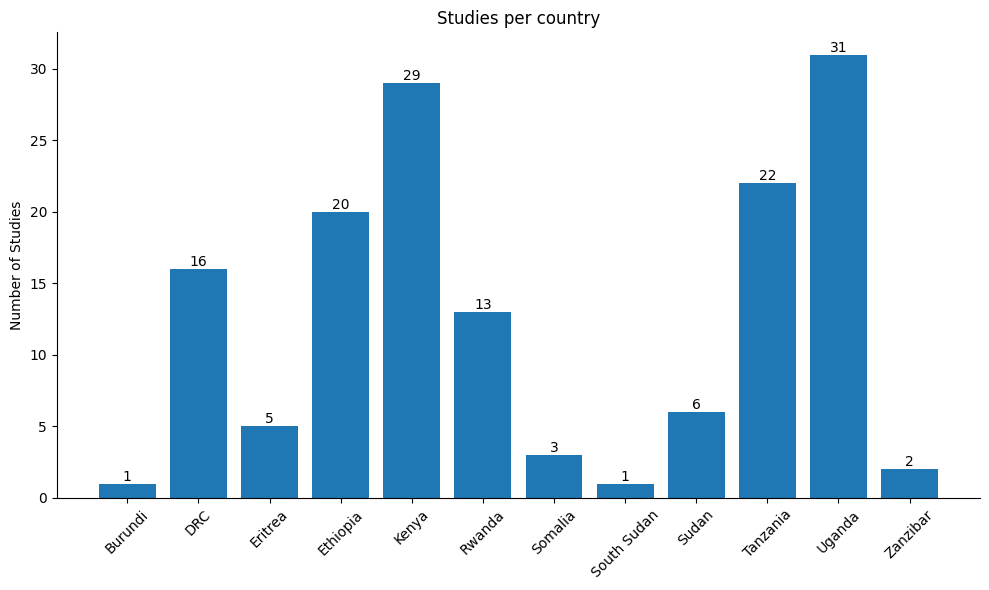

In [19]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country = validated_df.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

for bar in bars:
    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report.png", dpi=300, bbox_inches='tight')
plt.show()

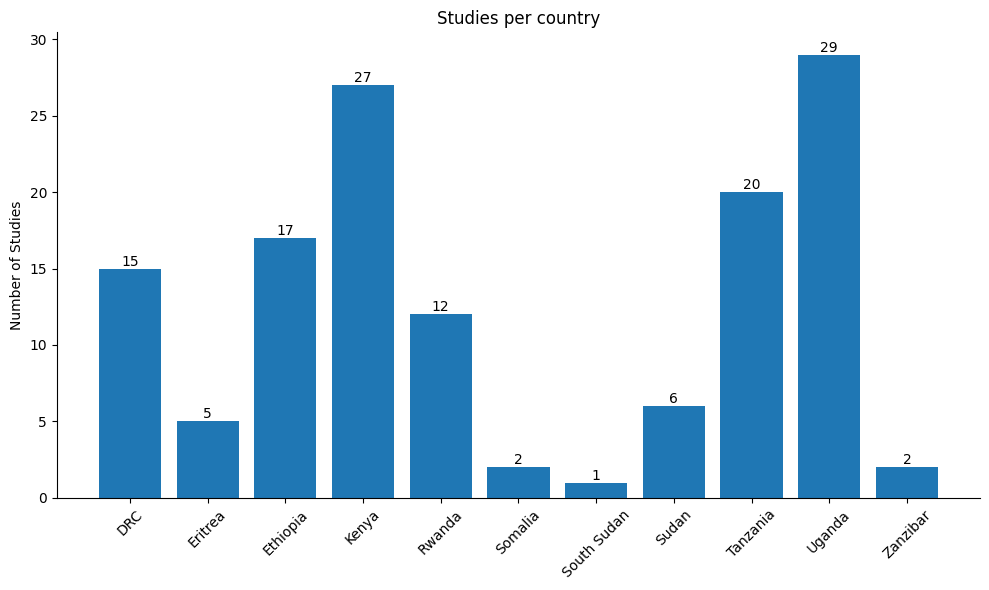

In [20]:
# Group by 'country' and calculate the number of unique 'pmid' for each country
country =nonval_df.groupby("country")["pmid"].nunique()

# Convert the Series to a DataFrame (index is automatically set by the groupby operation)
country_df = pd.DataFrame(country)

# Plotting
plt.figure(figsize=(10, 6))
bars = plt.bar(country_df.index, country_df["pmid"],)

for bar in bars:
    yval = bar.get_height()  # Get the height (number of unique PMIDs) of each bar
    plt.text(bar.get_x() + bar.get_width() / 2, yval, int(yval), ha="center", va="bottom")  # Label the bar
    
sns.despine(top=True, right=True)

# Adding labels and title
#plt.xlabel("Country")
plt.ylabel("Number of Studies")
plt.title("Studies per country")

# Show plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../results/paper_report1.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
validated_df[validated_df["country"] == "Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412', '10.2139/SSRN.4617870',
       '10.12688/wellcomeopenres.17656.1', '28535801', '39425178',
       '25367300', '27001814', '31591113', 40739505, 41420179, 41184373,
       39819451], dtype=object)

In [22]:
nonval_df[nonval_df["country"] == "Kenya"]["pmid"].unique()


array(['36036611', '34615917', '25180240', '34152946', '32795367',
       '35266823', '26801909', '26392510', '25695257', '39103358',
       '38287365', '37452073', '36894982', '36100912', '31756512',
       '29582728', '29363453', '34111412',
       '10.12688/Wellcomeopenres.17656.1', '28535801', '39425178',
       '31591113', '25367300', '27001814', 40739505, 41184373, 41420179],
      dtype=object)

In [23]:
validated_df[(validated_df["k13_validated_mutations"]=="A675V") & (validated_df["country"]=="Kenya")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),where_sequenced,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
397,38287365,2024,2021,Kenya,Western Kenya,Kakamega,>4,years,123,AL,...,A675V,non-synonymous,3 (25),missing,raw counts,open,3,25,0.28422,34.75229
895,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,A675V,non-synonymous,7.14,missing,percentage,open,3.8556,7.14,-,-
1067,41420179,2025,2024,Kenya,Kisumu,Ahero,missing,missing,1818,AL,...,A675V,non-synonymous,2(3.4),missing,raw count,open,2,3.4,-0.1724,34.919
1069,41420179,2025,2024,Kenya,Kisii,Marani,missing,missing,1818,AL,...,A675V,non-synonymous,14(27.5),missing,raw count,open,14,27.5,-0.5815,34.79562
1103,41184373,2025,2019,Kenya,Western,Bungoma,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,0.66,34.639
1104,41184373,2025,2019,Kenya,Western,Busia,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,0.35,34.17
1105,41184373,2025,2019,Kenya,Western,Homa Bay,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,-0.666,34.481
1106,41184373,2025,2019,Kenya,Western,Kakamega,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,0.334,34.797
1107,41184373,2025,2019,Kenya,Western,Kisumu,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,-0.069,34.64
1108,41184373,2025,2019,Kenya,Western,Migori,4-15,years,500,-,...,A675V,non-synonymous,0,International Livestock Research Institute,raw count,open,0,0,-0.982,34.409


In [24]:
papers_per_country_year = validated_df.groupby(["country", "year_pub"])["pmid"].nunique().reset_index()
papers_per_country_year.rename(columns={"pmid": "num_papers"}, inplace=True)


In [25]:
papers_per_country_year

,country,year_pub,num_papers
0,Burundi,2021,1
1,DRC,2014,2
2,DRC,2017,1
3,DRC,2018,1
4,DRC,2020,1
...,...,...,...
67,Uganda,2023,1
68,Uganda,2024,6
69,Uganda,2025,5
70,Zanzibar,2023,1


In [26]:
print(papers_per_country_year.head())


   country  year_pub  num_papers
0  Burundi      2021           1
1      DRC      2014           2
2      DRC      2017           1
3      DRC      2018           1
4      DRC      2020           1


In [27]:
pivot_table = papers_per_country_year.pivot(index="country", columns="year_pub", values="num_papers").fillna(0).astype(int)
pivot_table


year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country,,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,1,0,0,0,0
DRC,2,0,0,1,1,0,1,3,3,0,4,1
Eritrea,0,0,1,0,0,0,1,1,0,1,0,1
Ethiopia,1,2,0,1,0,1,0,1,1,2,4,7
Kenya,2,2,2,1,2,1,2,3,4,3,3,4
Rwanda,0,0,1,0,0,0,1,3,1,2,3,2
Somalia,0,0,0,0,0,1,0,1,0,1,0,0
South Sudan,0,0,0,0,0,0,0,0,0,1,0,0
Sudan,0,0,0,0,0,2,2,0,0,1,0,1


In [28]:
pivot_table.columns = pivot_table.columns.astype(int)
pivot_table

year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country,,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,1,0,0,0,0
DRC,2,0,0,1,1,0,1,3,3,0,4,1
Eritrea,0,0,1,0,0,0,1,1,0,1,0,1
Ethiopia,1,2,0,1,0,1,0,1,1,2,4,7
Kenya,2,2,2,1,2,1,2,3,4,3,3,4
Rwanda,0,0,1,0,0,0,1,3,1,2,3,2
Somalia,0,0,0,0,0,1,0,1,0,1,0,0
South Sudan,0,0,0,0,0,0,0,0,0,1,0,0
Sudan,0,0,0,0,0,2,2,0,0,1,0,1


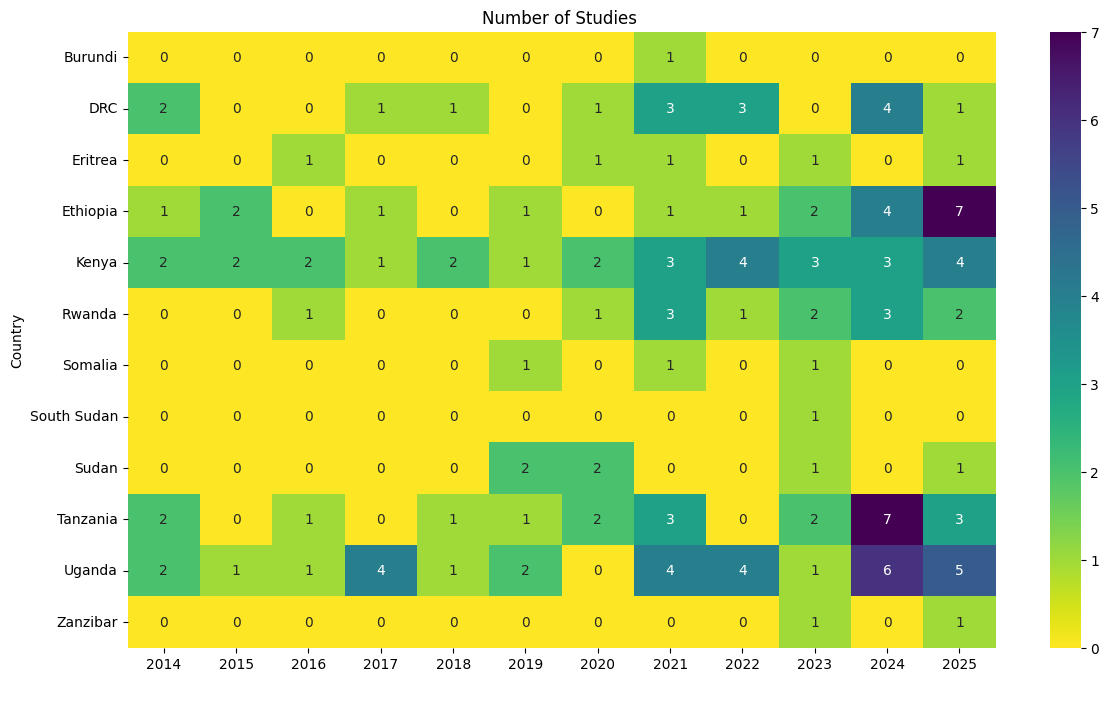

In [29]:
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, cmap="viridis_r", annot=True, fmt="d")
plt.title("Number of Studies ")
plt.xlabel(" ")
plt.ylabel("Country")
#plt.savefig("heatmap")
plt.show()


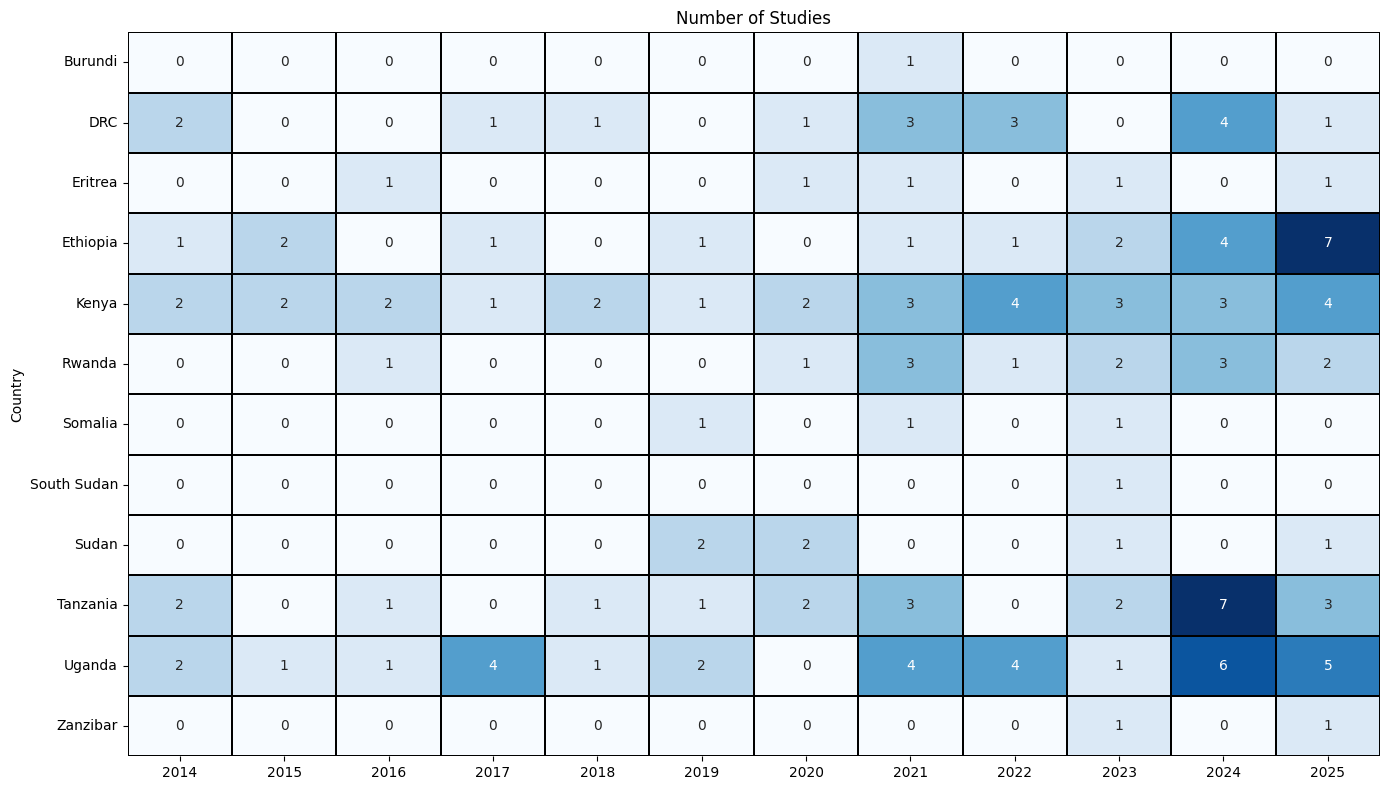

In [30]:
plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_table,
    annot=True,
    fmt="d",              # Display as integers
    cmap="Blues",         # Monochrome grayscale
    cbar=False,           # Hide the color bar
    linewidths=0.05,       # Optional: thin borders between cells
    linecolor='black' # Optional: border color
)

plt.title("Number of Studies")
plt.xlabel("")            # Optional: hide x-axis label
plt.ylabel("Country")

plt.tight_layout()
plt.savefig("../results/heatmap.png", dpi=300)
plt.show()


In [31]:
validated_df[(validated_df["country"]=="Tanzania") & (validated_df["year_pub"]==2024)]["pmid"].nunique()

7

In [32]:
print(plt.colormaps())

['magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted_r', 'turbo_r', 'Blues_r', 'BrBG_r', '

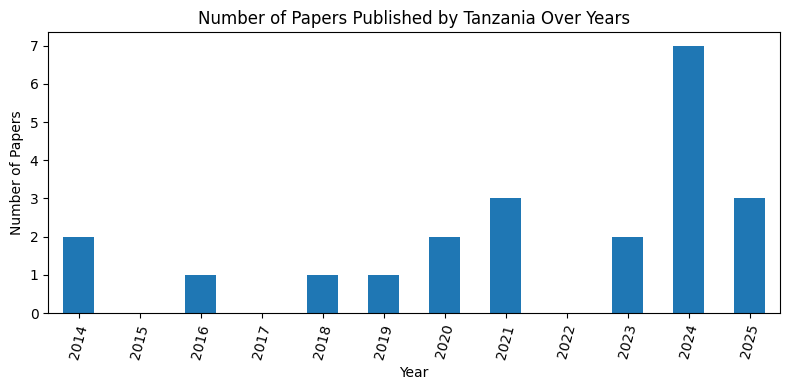

In [33]:
pivot_table.loc["Tanzania"].plot(kind="bar", figsize=(8, 4))
plt.title("Number of Papers Published by Tanzania Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Papers")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


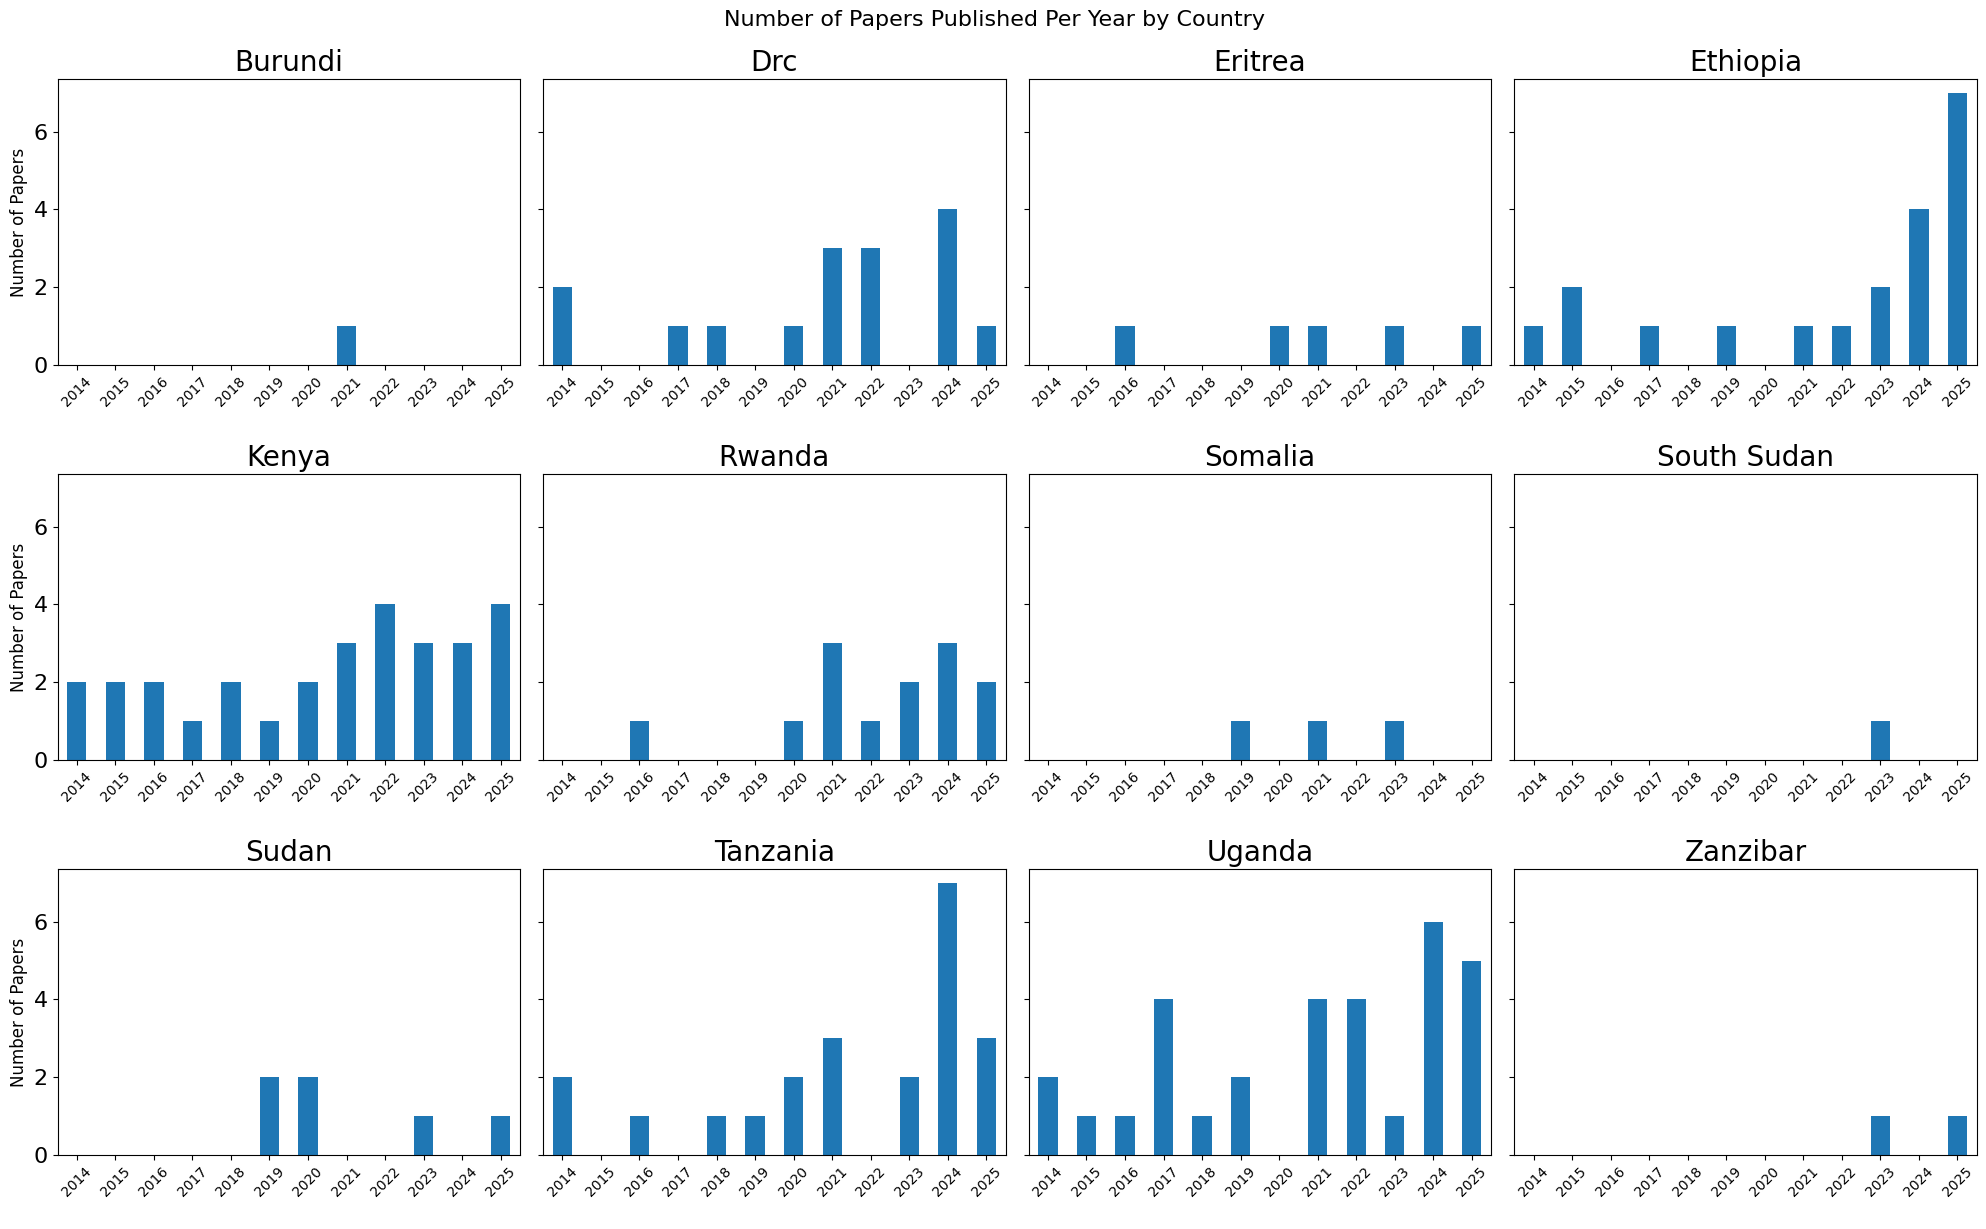

In [34]:
# Set number of countries and layout for subplots
countries = pivot_table.index.tolist()
n_countries = len(countries)

# Determine subplot grid size (e.g., 3 columns)
ncols = 4
nrows = -(-n_countries // ncols)  # Ceiling division

# Create subplots
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows *4), sharey=True)
axes = axes.flatten()  # Flatten in case it's 2D

# Plot each country's data
for i, country in enumerate(countries):
    ax = axes[i]
    pivot_table.loc[country].plot(kind="bar", ax=ax)
    ax.set_title(country.title(), fontsize=20)
    ax.set_xlabel(" ")
    ax.set_ylabel("Number of Papers", fontsize=12)
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    ax.tick_params(axis="y", labelsize=16)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Number of Papers Published Per Year by Country", fontsize=16, y=1.02)
plt.savefig("../results/papers_per_country.png", dpi=300)
plt.savefig("../results/papers_per_country.pdf")
plt.show()

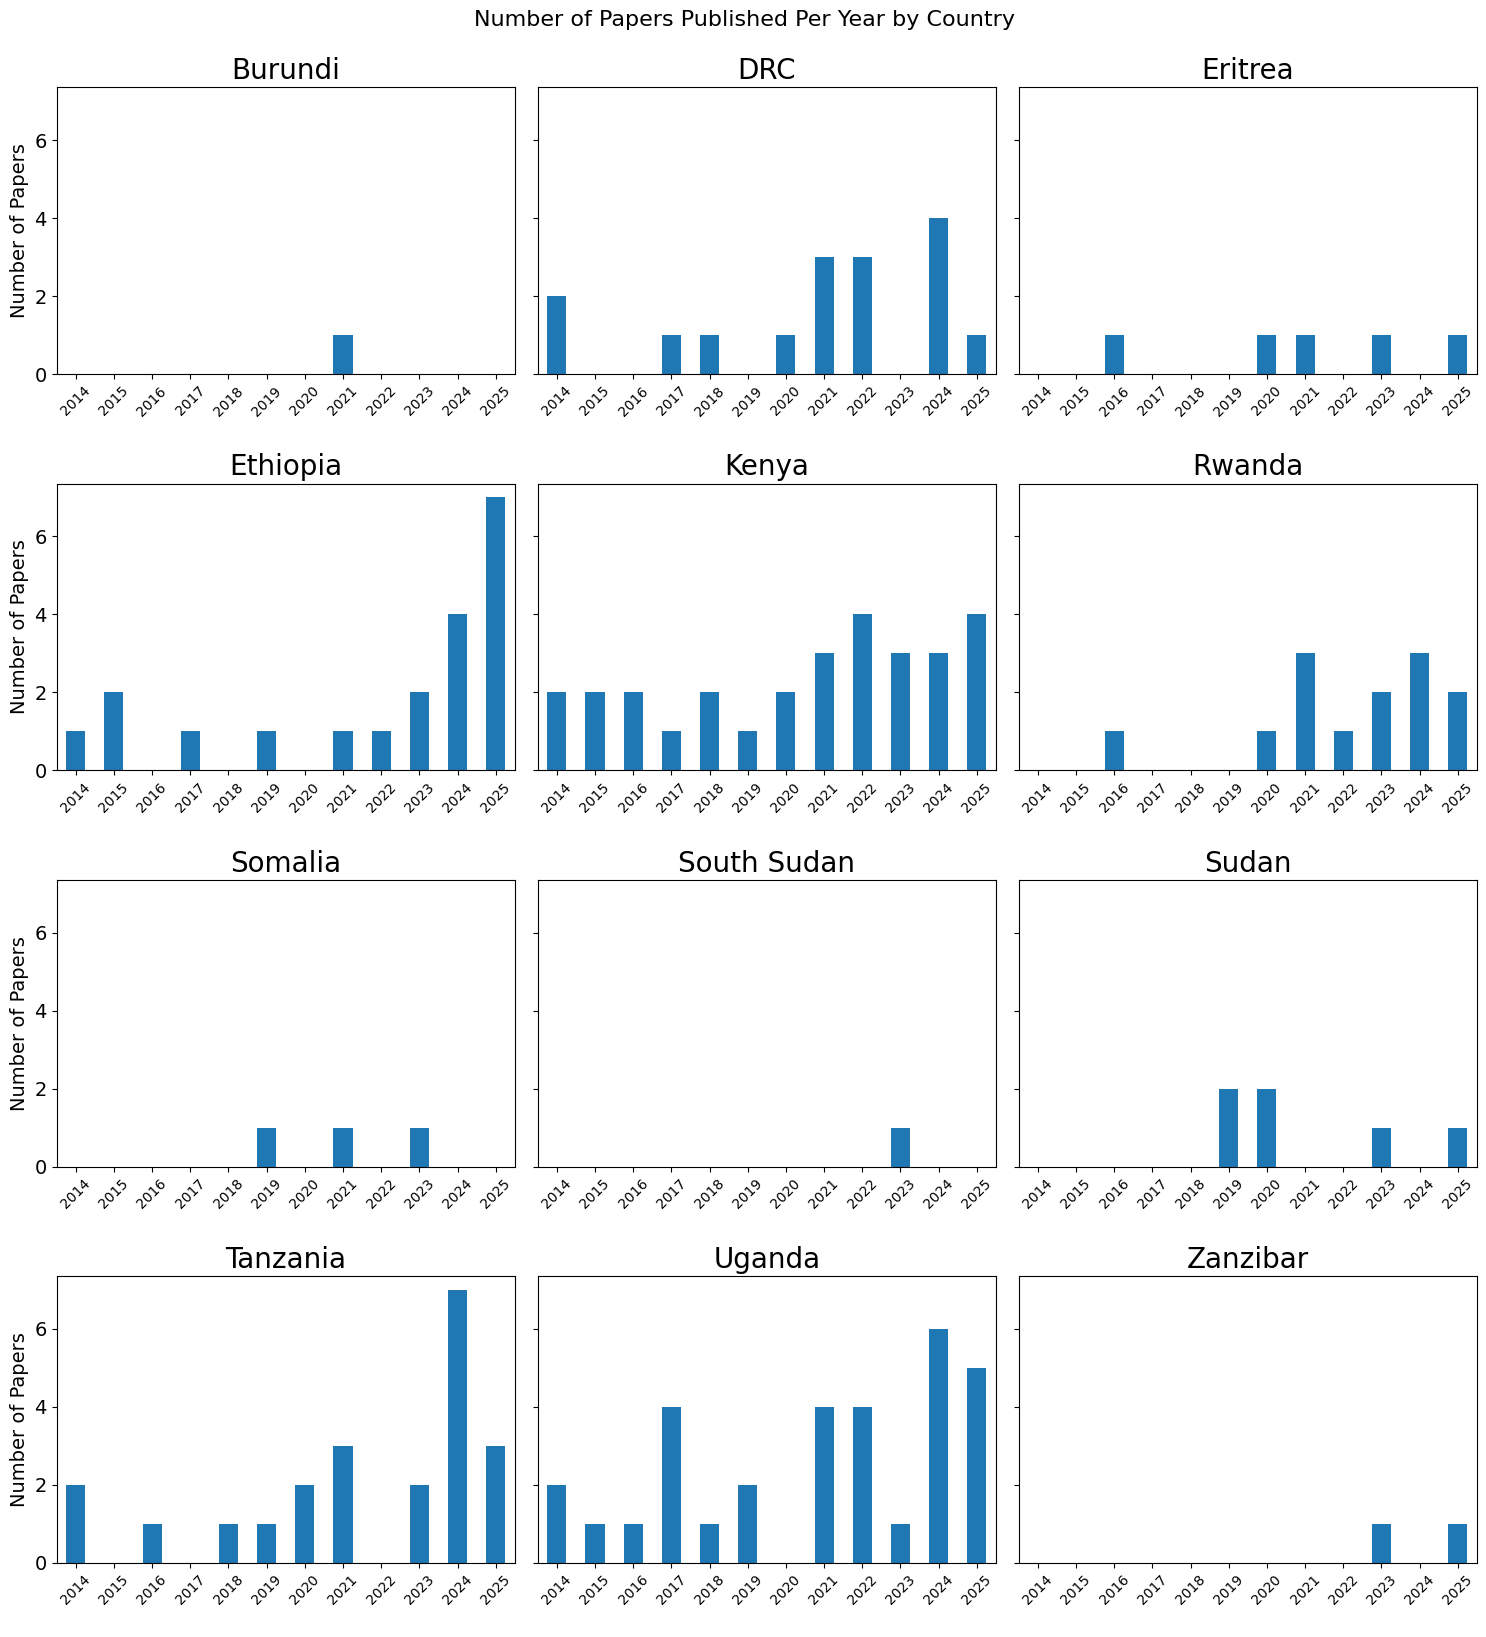

In [36]:
# Prepare country list and subplot grid layout
countries = pivot_table.index.tolist()
n_countries = len(countries)

ncols = 3
nrows = -(-n_countries // ncols)  # Ceiling division

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols * 5, nrows * 4), sharey=True)
axes = axes.flatten()

# Plot for each country
for i, country in enumerate(countries):
    ax = axes[i]
    data = pivot_table.loc[country]
    bars = data.plot(kind="bar", ax=ax)

    # Custom formatting
    title = "DRC" if country.strip().lower() == "drc" or country.strip().lower() == "drc" else country.title()
    ax.set_title(title, fontsize=20)
    ax.set_xlabel(" ")
    ax.set_ylabel("Number of Papers", fontsize=14)
    ax.tick_params(axis='x', rotation=45, labelsize= 10)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xticklabels([str(int(label.get_text())) for label in ax.get_xticklabels()])
    ax.set
    

    # Annotate bars with values
    #for bar in bars.patches:
     #   height = bar.get_height()
      #  if height > 0:
       #     ax.annotate(f'{int(height)}',
        #                (bar.get_x() + bar.get_width() / 2, height),
         #               ha='center', va='bottom', fontsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Number of Papers Published Per Year by Country", fontsize=16, y=1.02)
plt.savefig("temproral by country.png")
plt.show()

In [37]:
pivot_table

year_pub,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
country,,,,,,,,,,,,
Burundi,0,0,0,0,0,0,0,1,0,0,0,0
DRC,2,0,0,1,1,0,1,3,3,0,4,1
Eritrea,0,0,1,0,0,0,1,1,0,1,0,1
Ethiopia,1,2,0,1,0,1,0,1,1,2,4,7
Kenya,2,2,2,1,2,1,2,3,4,3,3,4
Rwanda,0,0,1,0,0,0,1,3,1,2,3,2
Somalia,0,0,0,0,0,1,0,1,0,1,0,0
South Sudan,0,0,0,0,0,0,0,0,0,1,0,0
Sudan,0,0,0,0,0,2,2,0,0,1,0,1


In [38]:
validated_df[validated_df["country"]=="Tanzania"]["pmid"].unique()

array(['39159629', '25180240', '34152946', '30898164', '38746440',
       '34270452', '32103124', '38876161', '38352311',
       '10.2139/SSRN.4617870', '34279219', '39159633', '37986920',
       '38461239', '33107096', '30333022', '25367300', '27001814',
       40598187, 40938322, 40802860, 39367758], dtype=object)

In [39]:
df_combined.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'sample_size', 'samples_genotyped', 'other_k13_mutations', 'Frequency',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude',
       'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)'],
      dtype='object')

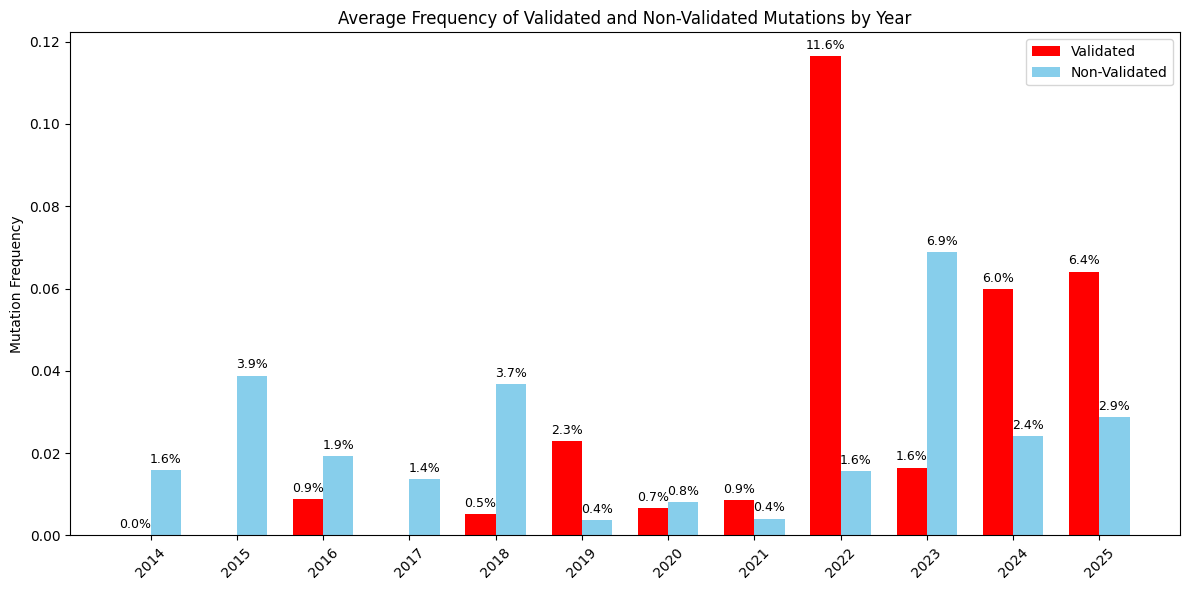

In [40]:
# Step 1: Copy relevant columns
df = df_combined[["year_pub",'k13_validated_mutations', "other_k13_mutations",
                  'mutation_frequency_(%)', "Frequency"]].copy()

# Step 2: Extract numerator and denominator from frequency strings
# For validated mutations
validated = df[df['k13_validated_mutations'].notna()].copy()
validated[["val_num", "val_den"]] = validated['mutation_frequency_(%)'].str.extract(r'(\d+)\s*/\s*(\d+)').astype(float)

# For non-validated mutations
non_validated = df[df["other_k13_mutations"].notna()].copy()
non_validated[["nonval_num", "nonval_den"]] = non_validated["Frequency"].str.extract(r'(\d+)\s*/\s*(\d+)').astype(float)

# Step 3: Group by year and sum numerator and denominator
val_grouped = validated.groupby("year_pub")[["val_num", "val_den"]].sum()
nonval_grouped = non_validated.groupby("year_pub")[["nonval_num", "nonval_den"]].sum()

# Step 4: Calculate total frequency per year
val_grouped["validated_freq"] = val_grouped["val_num"] / val_grouped["val_den"]
nonval_grouped["non_validated_freq"] = nonval_grouped["nonval_num"] / nonval_grouped["nonval_den"]

# Step 5: Merge the two frequency DataFrames on year
freq_df = pd.merge(val_grouped[["validated_freq"]], 
                   nonval_grouped[["non_validated_freq"]], 
                   left_index=True, right_index=True, how="outer").reset_index()

# Step 6: Plot side-by-side bars
x = np.arange(len(freq_df["year_pub"]))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, freq_df["validated_freq"], width, label="Validated", color="red")
bars2 = ax.bar(x + width/2, freq_df["non_validated_freq"], width, label="Non-Validated", color="skyblue")

# Add percentage labels on top
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1%}', 
                    xy=(bar.get_x() + bar.get_width()/2, height), 
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax.annotate(f'{height:.1%}', 
                    xy=(bar.get_x() + bar.get_width()/2, height), 
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

# Final touches
ax.set_xticks(x)
ax.set_xticklabels(freq_df["year_pub"], rotation=45)
ax.set_ylabel("Mutation Frequency")
ax.set_title("Average Frequency of Validated and Non-Validated Mutations by Year")
ax.legend()
plt.tight_layout()
plt.show()


# **Reading the version 6 excel**

In [134]:
validated_df1 = pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_validated_v8.xlsx")
validated_df1

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,≥0.5,years,77,AL,...,non-synonymous,0,missing,-,raw counts,open,0,0,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,≥0.5,years,77,AL,...,non-synonymous,0,missing,-,raw counts,open,0,0,2.85604,32.43001
2,34551228,2021,2016,Uganda,Northern-Uganda,Gulu,≥0.5,years,94,AL,...,non-synonymous,0,missing,-,raw counts,open,0,0,2.85604,32.43001
3,34551228,2021,2016,Uganda,Northern-Uganda,Gulu,≥0.5,years,94,AL,...,non-synonymous,3 (3.4),missing,-,raw counts,open,3,3.4,2.85604,32.43001
4,34551228,2021,2017,Uganda,Northern-Uganda,Gulu,≥0.5,years,101,AL,...,non-synonymous,0,missing,-,raw counts,open,0,0,2.85604,32.43001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1319,40681807,2025,2023,Ethiopia,Amhara,Woreta,>1,years,10,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,11.92367,37.69643
1320,40681807,2025,2023,Ethiopia,Amhara,Woreta,>1,years,10,missing,...,non-synonymous,10,Brown University,-,percentage,open,12,10,11.92367,37.69643
1321,40681807,2025,2023,Ethiopia,Amhara,Woreta,>1,years,10,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,11.92367,37.69643
1322,26875763,2016,2013-2014,Eritrea,"Gash Barka, Debub","Barentu, Agordat, Mdefera",1.5-70,years,200,ASAQ,...,-,0,Euroffins Genomis Company,-,none,closed,0,0,15.10567,37.58888


In [136]:
validated_df1["country"].unique()

array(['Uganda', 'DRC', 'Kenya', 'Ethiopia', 'Tanzania', 'Sudan',
       'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'Burundi',
       'South Sudan'], dtype=object)

In [137]:
# Fix country name mismatches manually (example)
country_name_map = {
     'DRC' : "Dem. Rep. Congo"
}

# Standardize names
validated_df1['country'] = validated_df1['country'].replace(country_name_map)


In [138]:
validated_df1["country"].unique()

array(['Uganda', 'Dem. Rep. Congo', 'Kenya', 'Ethiopia', 'Tanzania',
       'Sudan', 'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'Burundi',
       'South Sudan'], dtype=object)

In [139]:
validated_df1.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'k13_validated_mutations', 'type_of_mutation',
       'mutation_frequency_(%)', 'where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [140]:
validated_df1["k13_validated_mutations"].unique()

array(['C469Y', 'A675V', '-', 'R622I', 'C580Y', 'I543T', 'R539T', 'Y493H',
       'M476I', 'R561H', 'P553L', 'P574L', '-\t', 0, 'P441L'],
      dtype=object)

In [141]:
mutation_map={
    "561H" : "R561H",
    "675V" : "A675V",   
    
}

validated_df1["k13_validated_mutations"] = validated_df1["k13_validated_mutations"].replace(mutation_map)

In [142]:
validated_df1[validated_df1["country"]=="Sudan"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
85,31034031,2019,2015-2016,Sudan,South East Sudan,"Damazin, blue nile estate",missing,missing,31,AS+SP,...,-,0,macrogen,A621V,none,closed,NaN,NaN,11.8074,34.3656
350,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",F375S,none,open,NaN,NaN,11.8074,34.3656
351,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",K378R,none,open,NaN,NaN,11.8074,34.3656
352,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",D389N,none,open,NaN,NaN,11.8074,34.3656
353,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",K430K,none,open,NaN,NaN,11.8074,34.3656
354,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",E433D,none,open,NaN,NaN,11.8074,34.3656
355,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",P443P,none,open,NaN,NaN,11.8074,34.3656
356,32070355,2020,2015-2016,Sudan,South East Sudan,Damazin,missing,missing,130,AS+SP,...,-,0,"Wellcome Sanger Institute, UK",N594K,none,open,NaN,NaN,11.8074,34.3656
950,31369106,2019,2009-2016,Sudan,missing,missing,all ages,years,-,AS+SP,...,-,0,missing,-,none,closed,NaN,NaN,-,-
965,32817665,2020,2015-2017,Sudan,Central Sudan,Khartoum,missing,missing,158,AL,...,-,0,"Wellcome Sanger Institute, UK","K372K, K378R, D389H, K430E, E433D, L488L, A504...",raw counts,open,0,0,15.51026,32.54253


In [143]:
validated_df2=validated_df1.drop(columns=['participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population','where_sequenced', 'other_k13_mutations',
       'data_extraction_comments', 'journal_access'])

In [144]:
df_cleaned = validated_df2.drop_duplicates(subset=["pmid", "year_pub", "k13_validated_mutations"])
df_cleaned


,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,C469Y,non-synonymous,0,0,0,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,A675V,non-synonymous,0,0,0,2.85604,32.43001
10,35703955,2022,missing,Dem. Rep. Congo,Central DRC,Kinshasa,118,-,-,0,0,0,-4.375,15.97
11,36036611,2022,2016-2017,Kenya,Western Kenya,Siaya,340,-,-,0,0,0,0.06116,34.28823
12,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,C469Y,non-synonymous,6,6,0.54,0.41762,34.00421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1255,40681807,2025,2019,Ethiopia,SNNP,Lante,95,P574L,non-synonymous,0,0,0,6.251,36.5815
1256,40681807,2025,2019,Ethiopia,SNNP,Lante,95,R622I,non-synonymous,0,0,0,6.251,36.5815
1257,40681807,2025,2019,Ethiopia,SNNP,Lante,95,A675V,non-synonymous,0,0,0,6.251,36.5815
1322,26875763,2016,2013-2014,Eritrea,"Gash Barka, Debub","Barentu, Agordat, Mdefera",180,-,-,0,0,0,15.10567,37.58888


In [145]:
df_cleaned = df_cleaned[df_cleaned["k13_validated_mutations"].notna()]  # removes real NaN
df_cleaned = df_cleaned[df_cleaned["k13_validated_mutations"] != "-"]   # removes "-"
df_cleaned.head(30)

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
0,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,C469Y,non-synonymous,0,0,0,2.85604,32.43001
1,34551228,2021,2015,Uganda,Northern-Uganda,Gulu,77,A675V,non-synonymous,0,0,0,2.85604,32.43001
12,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,C469Y,non-synonymous,6,6,0.54,0.41762,34.00421
13,39136468,2024,2015-2023,Uganda,Eastern Uganda,"Tororo, Busia, Mbale",1112,A675V,non-synonymous,5,5,0.45,0.41762,34.00421
15,26483118,2015,2013-2014,Ethiopia,(Amhara Regional State)Northwest,Aykel,15,R622I,non-synonymous,1(6.7),1,6.7,12.54787,37.06321
21,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,339,C580Y,non-synonymous,0,0,0,-,-
22,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,I543T,non-synonymous,0,0,0,-,-
23,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,R539T,non-synonymous,0,0,0,-,-
24,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,Y493H,non-synonymous,0,0,0,-,-
25,29718283,2018,2013-2014,Dem. Rep. Congo,missing,missing,331,M476I,non-synonymous,0,0,0,-,-


In [146]:
print(plt.colormaps)

ColormapRegistry; available colormaps:
'magma', 'inferno', 'plasma', 'viridis', 'cividis', 'twilight', 'twilight_shifted', 'turbo', 'Blues', 'BrBG', 'BuGn', 'BuPu', 'CMRmap', 'GnBu', 'Greens', 'Greys', 'OrRd', 'Oranges', 'PRGn', 'PiYG', 'PuBu', 'PuBuGn', 'PuOr', 'PuRd', 'Purples', 'RdBu', 'RdGy', 'RdPu', 'RdYlBu', 'RdYlGn', 'Reds', 'Spectral', 'Wistia', 'YlGn', 'YlGnBu', 'YlOrBr', 'YlOrRd', 'afmhot', 'autumn', 'binary', 'bone', 'brg', 'bwr', 'cool', 'coolwarm', 'copper', 'cubehelix', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gist_yarg', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'seismic', 'spring', 'summer', 'terrain', 'winter', 'Accent', 'Dark2', 'Paired', 'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c', 'grey', 'gist_grey', 'gist_yerg', 'Grays', 'magma_r', 'inferno_r', 'plasma_r', 'viridis_r', 'cividis_r', 'twilight_r', 'twilight_shifted

In [147]:
validated_df2["percentage_frequency"].replace({'-':None}, inplace=True)

/tmp/ipykernel_14588/3692209037.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  validated_df2["percentage_frequency"].replace({'-':None}, inplace=True)


In [148]:
validated_df2['percentage_frequency'] = validated_df2["percentage_frequency"].astype(float)

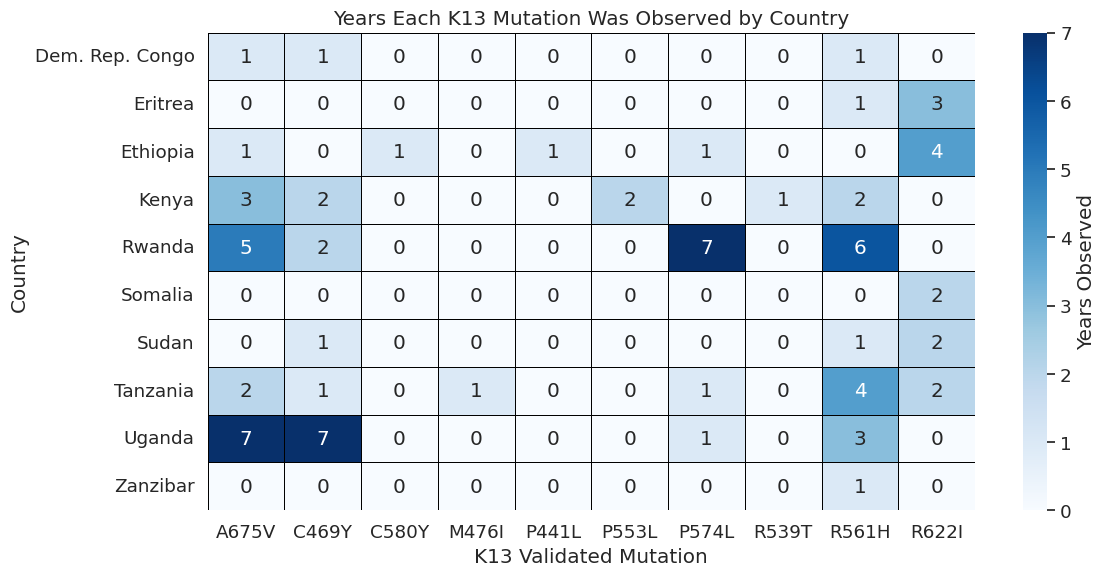

In [149]:
# Assuming your DataFrame is named `df`
# Step 1: Filter out rows with zero percentage frequency
df_filtered = validated_df2[validated_df2['percentage_frequency'] > 0]

# Step 2: Count the number of years each mutation was observed in each country
# Use drop_duplicates to avoid counting the same mutation in the same year more than once
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["k13_validated_mutations"] != "-"]
heatmap_data = df_unique.groupby(['country', 'k13_validated_mutations']).size().unstack(fill_value=0)

# Step 3: Plot the heatmap
plt.figure(figsize=(12, 6))
sns.set(font_scale=1.2)

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap="Blues", linewidths=0.5, linecolor="black", cbar_kws={'label': 'Years Observed'})

plt.title("Years Each K13 Mutation Was Observed by Country")
plt.xlabel("K13 Validated Mutation")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


In [150]:
validated_df2[validated_df2["pmid"]== 36289202]

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude


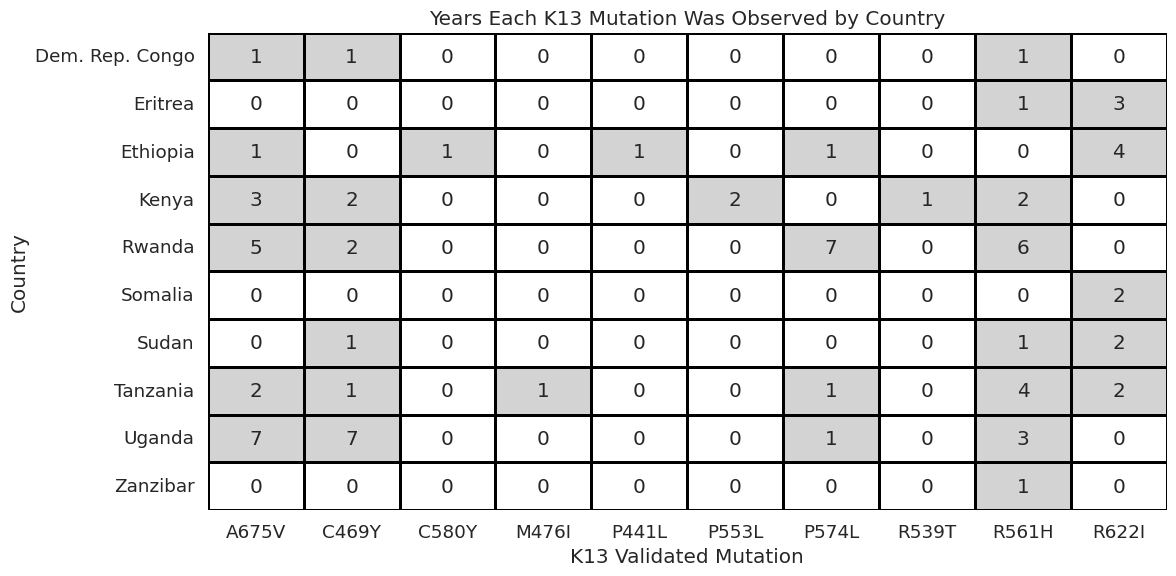

In [151]:
# Step 1: Filter out rows with zero percentage frequency
df_filtered = validated_df2[validated_df2['percentage_frequency'] > 0]

# Step 2: Remove duplicates and exclude a specific PMID
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["k13_validated_mutations"] != "-"]

# Step 3: Create heatmap data
heatmap_data = df_unique.groupby(['country', 'k13_validated_mutations']).size().unstack(fill_value=0)

# Step 4: Create a binary colormap: white for 0, grey for >0
colors = ["white", "lightgrey"]
cmap = mcolors.ListedColormap(colors)

# Normalize: 0 → 0, all others → 1
bounds = [0, 0.5, heatmap_data.values.max() + 1]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Step 5: Plot the heatmap
plt.figure(figsize=(12, 6))
sns.set(font_scale=1.2)

sns.heatmap(heatmap_data, annot=True, fmt="d", cmap=cmap, norm=norm,
            linewidths=1.0, linecolor="black", cbar=False)  # cbar=False to remove irrelevant color bar

plt.title("Years Each K13 Mutation Was Observed by Country")
plt.xlabel("K13 Validated Mutation")
plt.ylabel("Country")
plt.tight_layout()
plt.savefig("../years_k13_observed.png", dpi=300)
plt.show()


In [152]:
df_unique["country"].unique()

array(['Uganda', 'Ethiopia', 'Tanzania', 'Kenya', 'Rwanda',
       'Dem. Rep. Congo', 'Somalia', 'Eritrea', 'Sudan', 'Zanzibar'],
      dtype=object)

In [153]:
df_unique[(df_unique["k13_validated_mutations"]=="-") & (df_unique["country"]=="Uganda")]


,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude


In [154]:
cols = ["k13_validated_mutations"]
validated_df1 = validated_df1[~validated_df1[cols].eq("-").any(axis=1)]


In [155]:
for col, val in {"latitude": 12.6104, "longitude": 37.4668}.items():
    validated_df1.loc[
        validated_df1["pmid"] == "10.2139/ssrn.4938046", col
    ] = validated_df1.loc[
        validated_df1["pmid"] == "10.2139/ssrn.4938046", col
    ].replace('-', val)

/tmp/ipykernel_14588/4034252479.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].replace('-', val)
/tmp/ipykernel_14588/4034252479.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ].replace('-', val)


/tmp/ipykernel_14588/958386079.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid


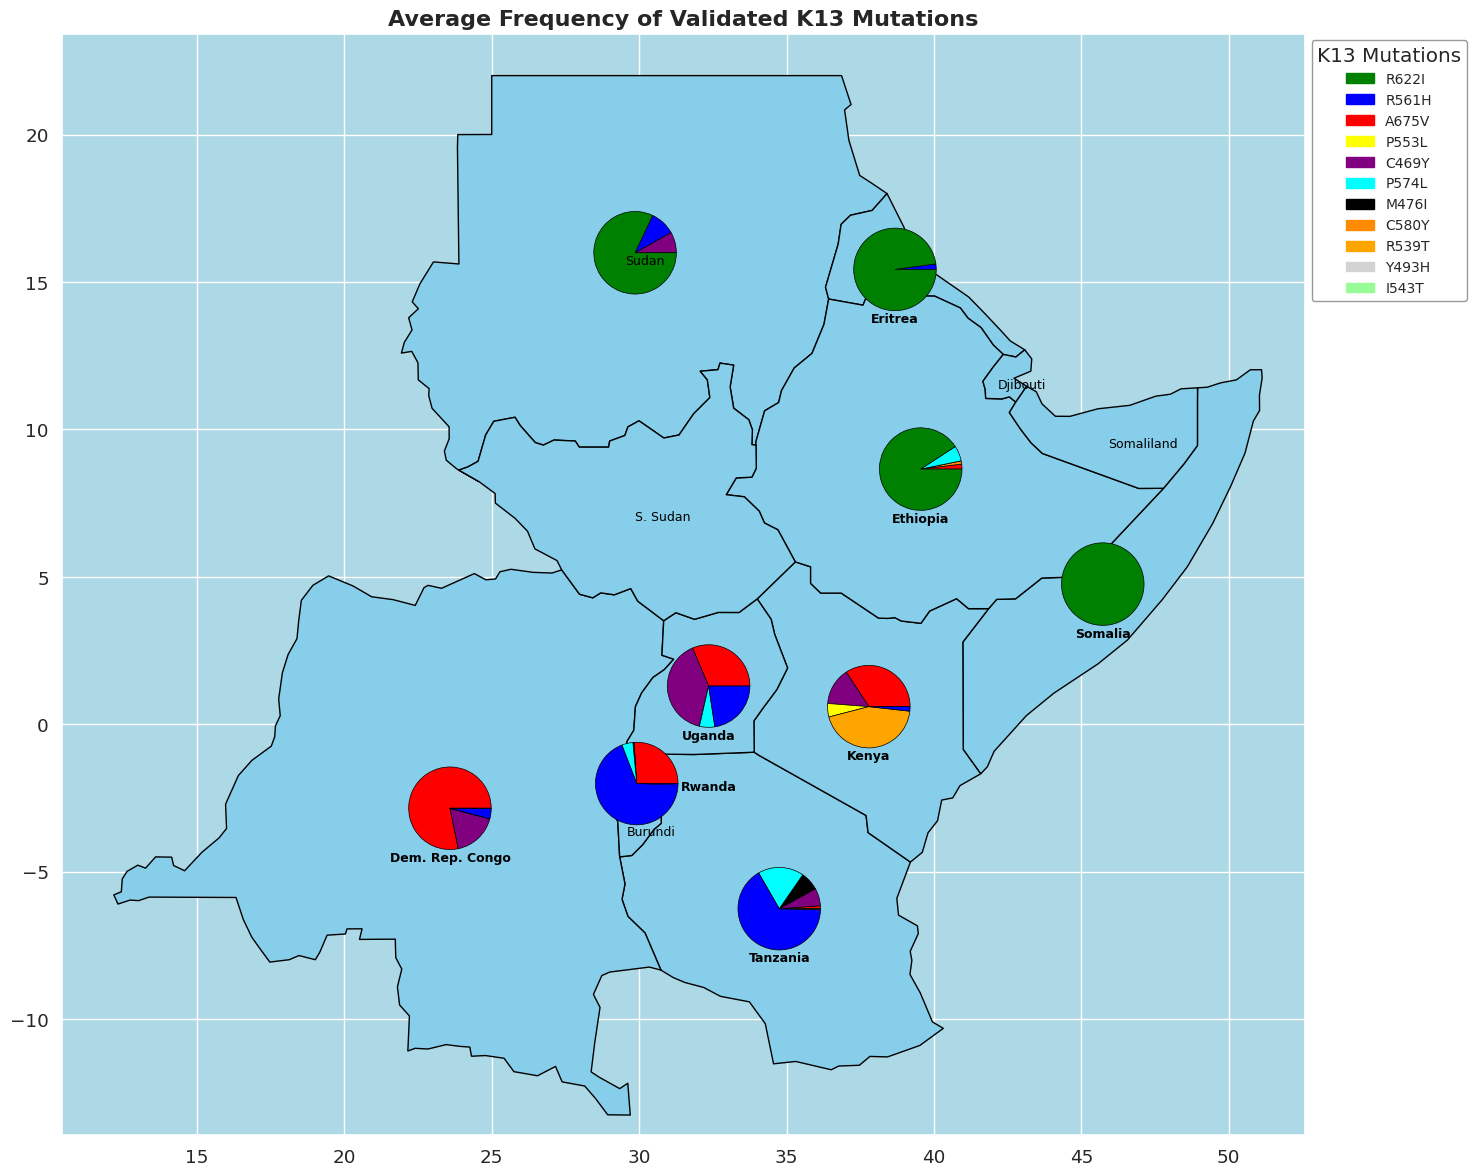

In [156]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

valid_mutations = list(mutation_colors.keys())

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df_clean = validated_df1[
    validated_df1['k13_validated_mutations'].isin(valid_mutations)
].dropna(subset=['longitude', 'latitude', 'percentage_frequency'])

# ----------------------------
# GROUP BY COUNTRY & MUTATION: average frequency
# ----------------------------
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# ----------------------------
# LOAD WORLD MAP & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# GET CENTROIDS FOR COUNTRY LABELING
# ----------------------------
world_centroids = world_filtered[['NAME', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
world_centroids = world_centroids.rename(columns={'NAME': 'country'})

# ----------------------------
# MERGE frequencies with centroid coords
# ----------------------------
coords = world_centroids[['country', 'latitude', 'longitude']]
plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------
def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# DRAW THE MAP AND PIES
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 12))
world_filtered.plot(ax=ax, color='skyblue', edgecolor='black')
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 

# Draw pie charts
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]

    draw_proportional_pie(ax, lon, lat, muts, freqs, radius=1.4)

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_aspect('equal', adjustable='datalim')
ax.autoscale(enable=False)

# Centered on East/Central Africa
ax.set_xlim(20, 43)
ax.set_ylim(-12, 21.5)

# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax.legend(handles=legend_handles, title='K13 Mutations',
                   loc='upper left', bbox_to_anchor=(1, 1),
                   borderaxespad=0.5, fontsize=10)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Annotate country names with specific styles
# Annotate country names with specific styles
exclude_countries = ['S. Sudan', 'Sudan', 'Burundi', 'Somaliland', 'Djibouti']

for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']

    if country == 'Rwanda':
        # Side label with dashed leader line
        label_x = x + 1.5  # shift right
        label_y = y - 0.1  # slight vertical shift
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=9,
            color='black',
            ha='left',
            weight="bold",
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                linestyle='dashed',
                color='black',
                lw=0.5
            )
        )
    elif country in exclude_countries:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(-7, -8),
            textcoords="offset points",
            fontsize=9,
            color='black'
        )
    else:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, -38),
            textcoords="offset points",
            ha='center',
            fontsize=9,
            color='black',
            weight='bold'
        )

plt.title('Average Frequency of Validated K13 Mutations', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../results/validated_mutations_africa_subset.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14588/2763208620.py:59: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid


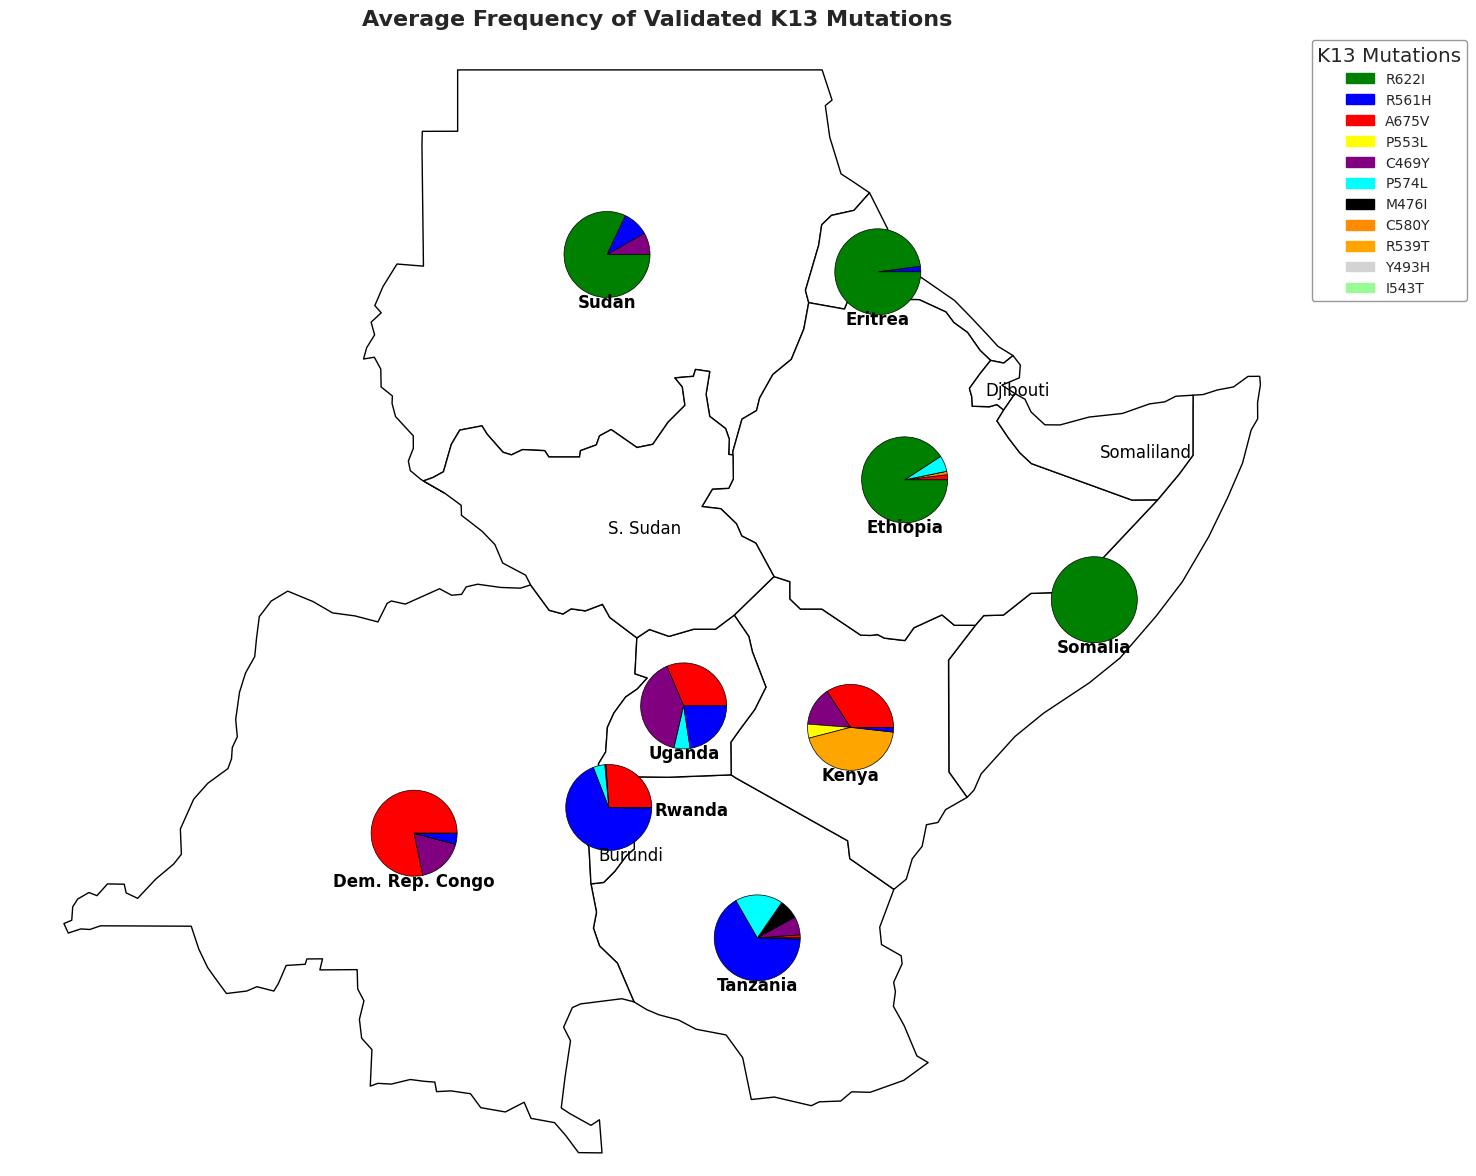

In [157]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

valid_mutations = list(mutation_colors.keys())

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df_clean = validated_df1[
    validated_df1['k13_validated_mutations'].isin(valid_mutations)
].dropna(subset=['longitude', 'latitude', 'percentage_frequency'])

# ----------------------------
# GROUP BY COUNTRY & MUTATION: average frequency
# ----------------------------
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# ----------------------------
# LOAD WORLD MAP & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# GET CENTROIDS FOR COUNTRY LABELING
# ----------------------------
world_centroids = world_filtered[['NAME', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
world_centroids = world_centroids.rename(columns={'NAME': 'country'})

# ----------------------------
# MERGE frequencies with centroid coords
# ----------------------------
coords = world_centroids[['country', 'latitude', 'longitude']]
plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------
def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# DRAW THE MAP AND PIES
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 12))
world_filtered.plot(ax=ax, color='white', edgecolor='black')
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 

# Draw pie charts
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]

    draw_proportional_pie(ax, lon, lat, muts, freqs, radius=1.4)

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_aspect('equal', adjustable='datalim')
ax.autoscale(enable=False)

# Centered on East/Central Africa
ax.set_xlim(20, 43)
ax.set_ylim(-12, 21.5)
ax.axis("off")
# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax.legend(handles=legend_handles, title='K13 Mutations',
                   loc='upper left', bbox_to_anchor=(1, 1),
                   borderaxespad=0.5, fontsize=10)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Annotate country names with specific styles
# Annotate country names with specific styles
exclude_countries = ['S. Sudan', 'Burundi', 'Somaliland', 'Djibouti']

for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']

    if country == 'Rwanda':
        # Side label with dashed leader line
        label_x = x + 1.5  # shift right
        label_y = y - 0.1  # slight vertical shift
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=12,
            color='black',
            ha='left',
            weight="bold",
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                linestyle='dashed',
                color='black',
                lw=0.5
            )
        )
    elif country in exclude_countries:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(-7, -8),
            textcoords="offset points",
            fontsize=12,
            color='black'
        )
    else:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, -38),
            textcoords="offset points",
            ha='center',
            fontsize=12,
            color='black',
            weight='bold'
        )

plt.title('Average Frequency of Validated K13 Mutations', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../results/validated_mutations_africa_plain.png", dpi=300, bbox_inches='tight')
plt.show()

In [158]:
df_clean[df_clean["pmid"]=='34279219']

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
899,34279219,2021,2012-2015,Rwanda,missing,missing,missing,missing,927,AL,...,non-synonymous,1/927,"Institut Pasteur, Paris","M460I, V487I, A578V, A626E, G592E+V637I",raw counts,open,1,0.11,-2,29.88
900,34279219,2021,2012-2015,Rwanda,missing,missing,missing,missing,927,AL,...,non-synonymous,20/927,"Institut Pasteur, Paris","C469F, R513L, A578S, P667R",raw counts,open,20,2.16,-2,29.88
901,34279219,2021,2012-2015,Rwanda,missing,missing,missing,missing,927,AL,...,non-synonymous,1/927,"Institut Pasteur, Paris","V555A, R575I, E605K, E651K",raw counts,open,1,0.11,-2,29.88
902,34279219,2021,2016-2017,Somalia,missing,missing,missing,missing,138,AL,...,non-synonymous,1/138,"Institut Pasteur, Paris",-,raw counts,open,1,0.72,-,-
903,34279219,2021,"2011, 2012, 2015",Tanzania,missing,missing,missing,missing,235,AL,...,non-synonymous,1/235,"Institut Pasteur, Paris","L463S, G496S, V510M, E556K, M562T, E602D",raw counts,open,1,0.43,-6,34.6


In [159]:
df_clean[(df_clean["longitude"]=="-")&(df_clean["percentage_frequency"] != 0)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
894,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,non-synonymous,4.76,missing,-,percentage,open,2.5704,4.76,-,-
895,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,missing,missing,-,AL,...,non-synonymous,7.14,missing,-,percentage,open,3.8556,7.14,-,-
902,34279219,2021,2016-2017,Somalia,missing,missing,missing,missing,138,AL,...,non-synonymous,1/138,"Institut Pasteur, Paris",-,raw counts,open,1,0.72,-,-


In [160]:
# Replace "-" with np.nan in longitude and latitude
validated_df1['longitude'] = validated_df1['longitude'].replace('-', np.nan)
validated_df1['latitude'] = validated_df1['latitude'].replace('-', np.nan)

# Convert to numeric (in case other non-numeric values exist)
validated_df1['longitude'] = pd.to_numeric(validated_df1['longitude'], errors='coerce')
validated_df1['latitude'] = pd.to_numeric(validated_df1['latitude'], errors='coerce')


/tmp/ipykernel_14588/1380314678.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  validated_df1['longitude'] = validated_df1['longitude'].replace('-', np.nan)
/tmp/ipykernel_14588/1380314678.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validated_df1['longitude'] = validated_df1['longitude'].replace('-', np.nan)
/tmp/ipykernel_14588/1380314678.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_ob

/tmp/ipykernel_14588/2068584231.py:66: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


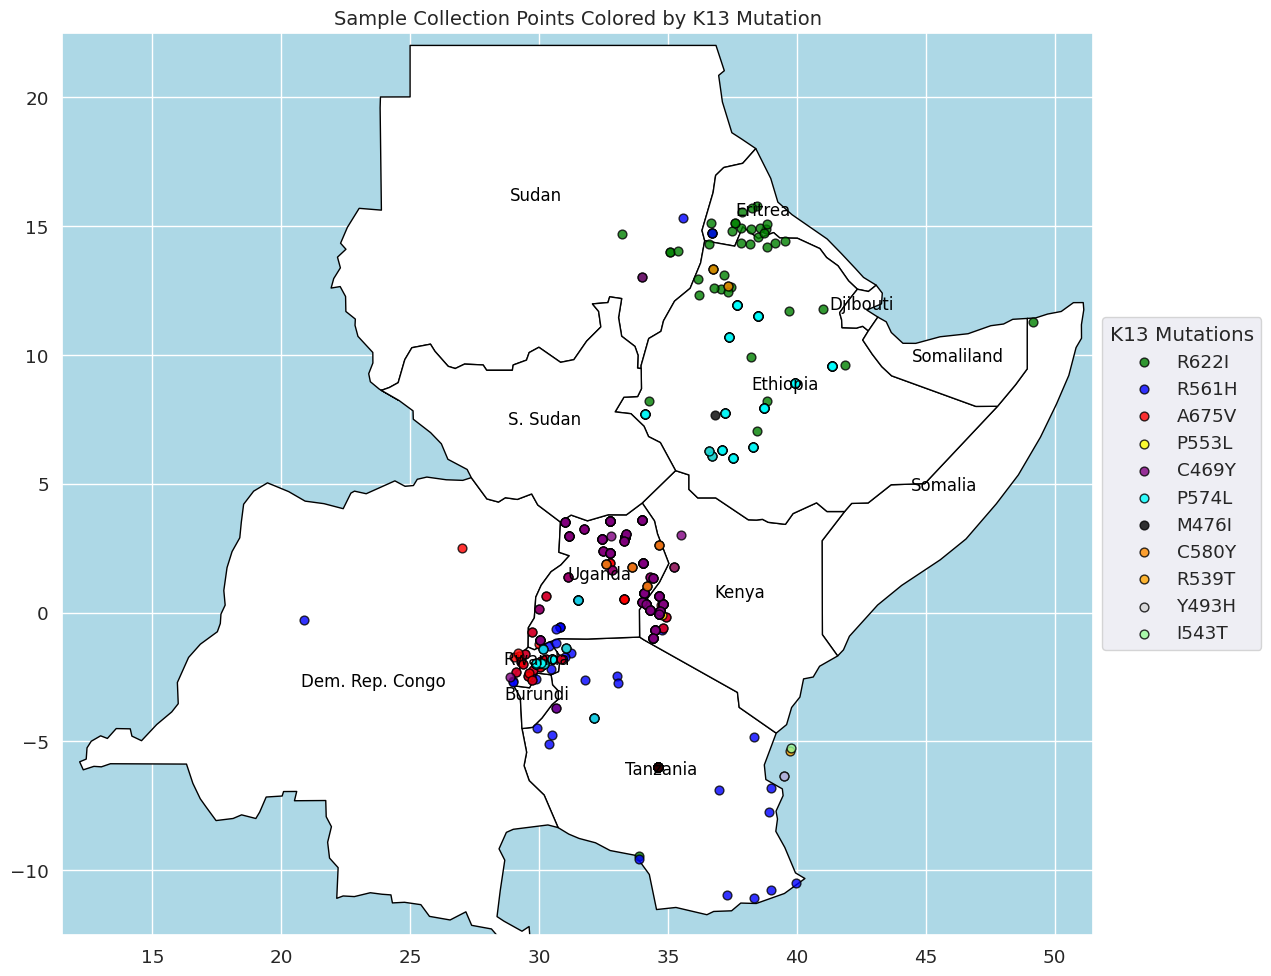

In [161]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}
# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude','percentage_frequency'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# Match country names (ensure correct column is used, e.g., 'NAME')
world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAP WITH SAMPLE POINTS
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 
# Plot base map (filtered African countries)
world_africa.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points by mutation
for mutation, color in mutation_colors.items():
    subset = df[df['k13_validated_mutations'] == mutation]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES
# ----------------------------
# Compute centroids for labeling
world_africa['centroid'] = world_africa.geometry.centroid

for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis("on")


plt.title('Sample Collection Points Colored by K13 Mutation', fontsize=14)
plt.tight_layout()
plt.savefig("../results/sample_collection_points_labeled.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14588/989415875.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_14588/989415875.py:80: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
/tmp/ipykerne

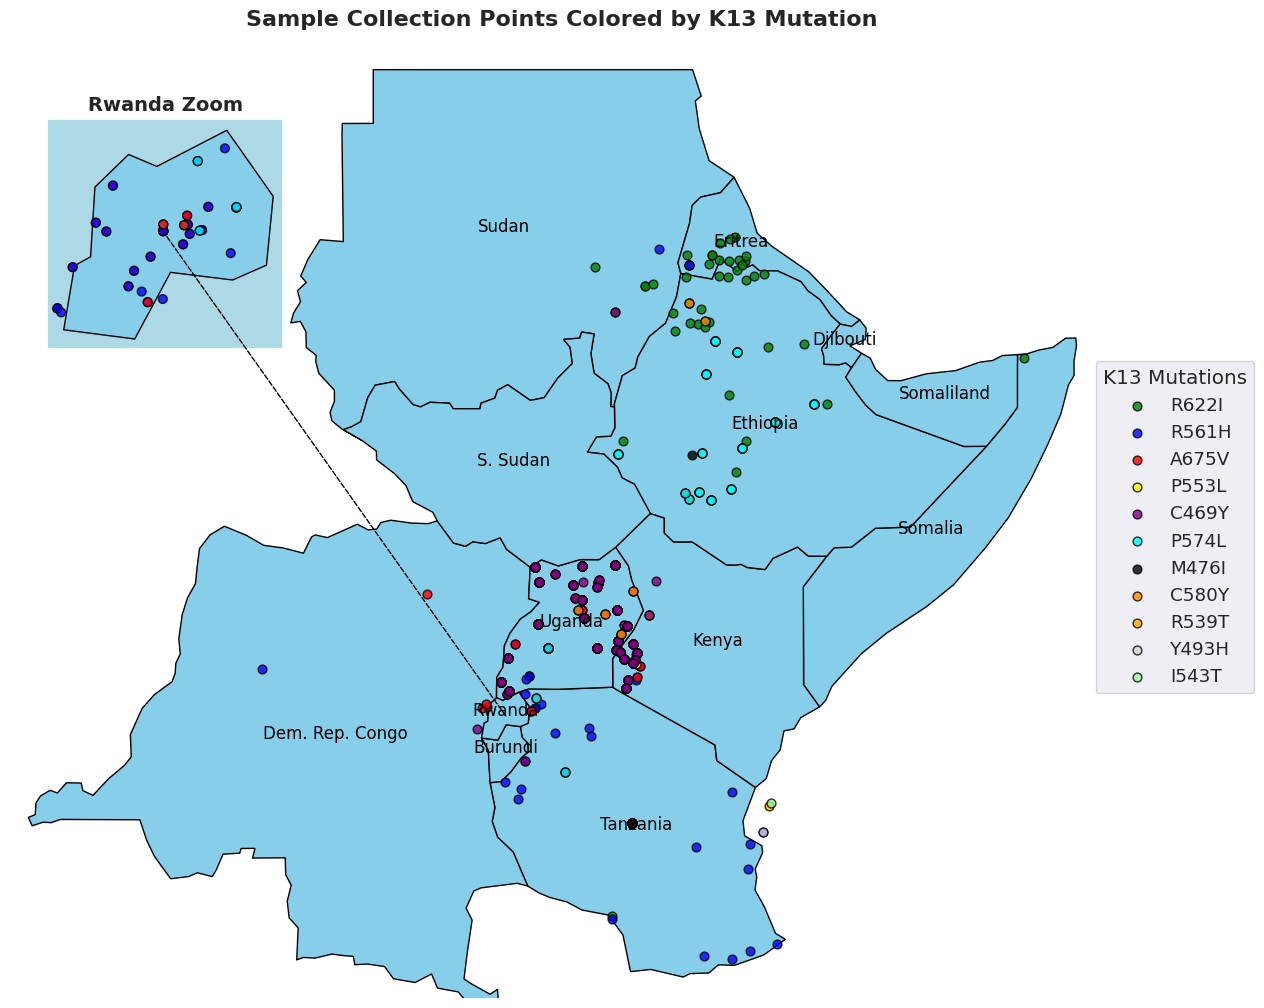

In [162]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
#world=gpd.read_file("../ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp")
# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAIN MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot African countries
world_africa.plot(ax=ax, color='skyblue', edgecolor='black')

# Plot sample points by mutation (excluding Rwanda)
for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES ON MAIN MAP
# ----------------------------
world_africa['centroid'] = world_africa.geometry.centroid
for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# INSET MAP FOR RWANDA
# ----------------------------
# Get Rwanda geometry
rwanda_shape = world_africa[world_africa['NAME'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]

# Create inset axes
ax_inset = inset_axes(ax, width="22%", height="30%", loc='upper left', borderpad=2)
ax_inset.set_facecolor('lightblue')

# Plot Rwanda only
rwanda_shape.plot(ax=ax_inset, color='skyblue', edgecolor='black')

# Plot mutation points in Rwanda
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)

ax_inset.set_title('Rwanda Zoom', fontsize=14, weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# ----------------------------
# Add a line from main map to inset
# ----------------------------
# Connect from Rwanda centroid on main map to inset
con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)


# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

# Legend
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis('off')
# Save & Show
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Leaves just a bit of space for the title
plt.suptitle('Sample Collection Points Colored by K13 Mutation', fontsize=16, weight='bold', y=1.01)
plt.savefig("../results/sample_collection_points_labeled_rwanda1.png", dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_14588/1729255318.py:67: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/home/kimani/miniconda3/envs/PopStruct/lib/python3.13/site-packages/geopandas/geodataframe.py:1819: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_14588/1729255318.py:80: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
/tmp/ipyker

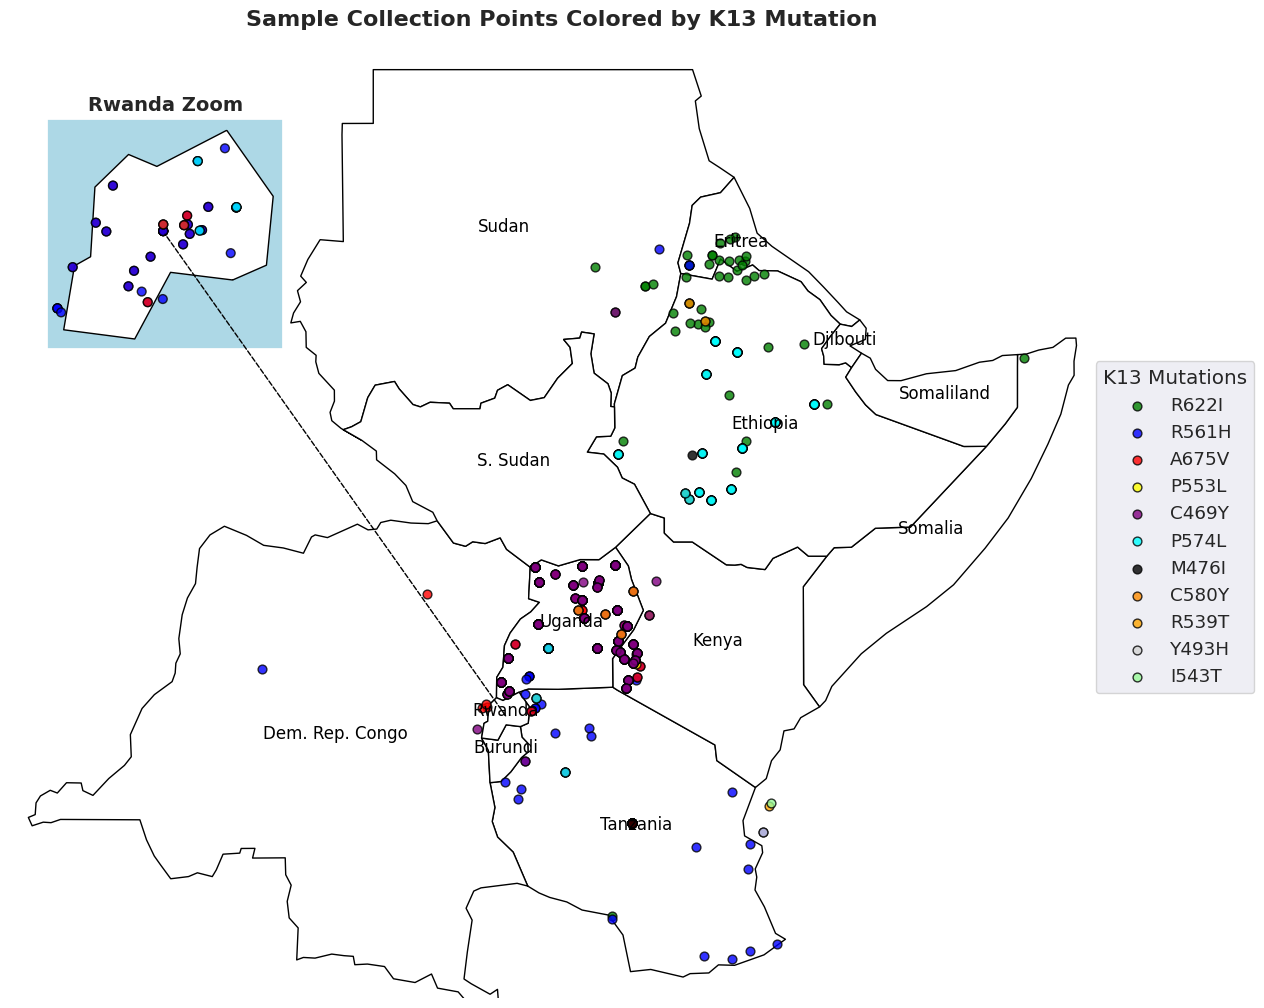

In [163]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

# ----------------------------
# CLEAN DATA
# ----------------------------
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
#world=gpd.read_file("../ne_50m_admin_1_states_provinces/ne_50m_admin_1_states_provinces.shp")
# ----------------------------
# FILTER TO AFRICAN COUNTRIES OF INTEREST
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

world_africa = world[world['NAME'].isin(african_countries)]

# ----------------------------
# PLOT MAIN MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot African countries
world_africa.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points by mutation (excluding Rwanda)
for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# LABEL COUNTRIES ON MAIN MAP
# ----------------------------
world_africa['centroid'] = world_africa.geometry.centroid
for _, row in world_africa.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# INSET MAP FOR RWANDA
# ----------------------------
# Get Rwanda geometry
rwanda_shape = world_africa[world_africa['NAME'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]

# Create inset axes
ax_inset = inset_axes(ax, width="22%", height="30%", loc='upper left', borderpad=2)
ax_inset.set_facecolor('lightblue')

# Plot Rwanda only
rwanda_shape.plot(ax=ax_inset, color='white', edgecolor='black')

# Plot mutation points in Rwanda
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)

ax_inset.set_title('Rwanda Zoom', fontsize=14, weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# ----------------------------
# Add a line from main map to inset
# ----------------------------
# Connect from Rwanda centroid on main map to inset
con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)


# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

# Legend
ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis('off')
# Save & Show
plt.tight_layout(rect=[0, 0, 1, 0.985])  # Leaves just a bit of space for the title
plt.suptitle('Sample Collection Points Colored by K13 Mutation', fontsize=16, weight='bold', y=1.01)
plt.savefig("../results/sample_collection_points_labeled_rwanda_white.png", dpi=300, bbox_inches='tight')
plt.show()

In [164]:
world[world["NAME"]=="Zanzibar"]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry


In [165]:
world1=gpd.read_file("../ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp")

In [166]:
world1[world1["NAME"]=="Zanzibar"]

,featurecla,scalerank,LABELRANK,SOVEREIGNT,SOV_A3,ADM0_DIF,LEVEL,TYPE,TLC,ADMIN,...,FCLASS_TR,FCLASS_ID,FCLASS_PL,FCLASS_GR,FCLASS_IT,FCLASS_NL,FCLASS_SE,FCLASS_BD,FCLASS_UA,geometry


In [167]:
validated_df1[(validated_df1["country"]=="Kenya")&(validated_df1["k13_validated_mutations"]=="R622I")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude


In [168]:
validated_df2[validated_df2["year_sample"]=='2000-2007']

,pmid,year_pub,year_sample,country,region/province,town,samples_genotyped,k13_validated_mutations,type_of_mutation,mutation_frequency_(%),raw_count,percentage_frequency,latitude,longitude
894,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,54,R539T,non-synonymous,4.76,2.5704,4.76,-,-
895,10.2139/SSRN.4617870,2023,2000-2007,Kenya,missing,missing,54,A675V,non-synonymous,7.14,3.8556,7.14,-,-


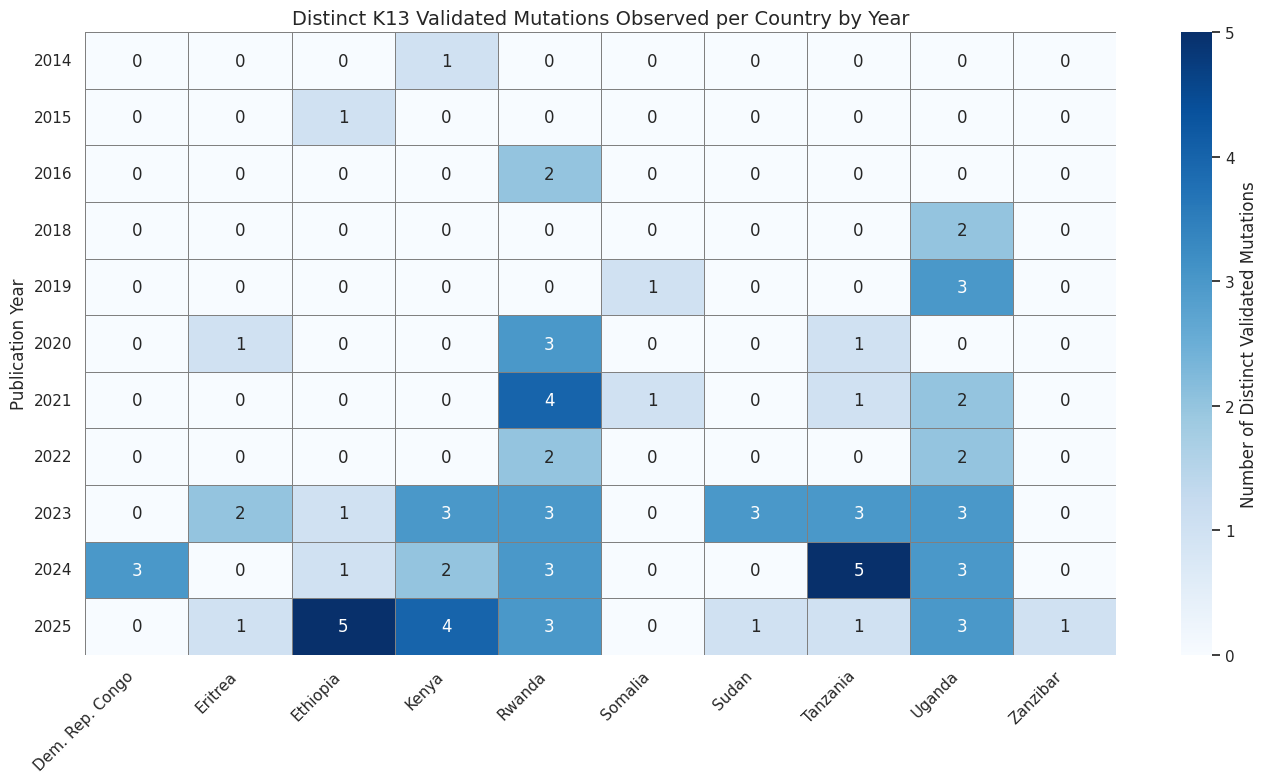

In [169]:
# Step 1: Filter rows with percentage_frequency > 0 and valid mutations
df_filtered = validated_df1[validated_df1['percentage_frequency'] > 0]

# Step 2: Drop duplicates (mutation, country, year) to avoid overcounting
df_unique = df_filtered.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])
df_unique = df_unique[df_unique["year_pub"] != 2028]

# Step 3: Group by year and country, count unique validated mutations
heatmap_data = (
    df_unique
    .groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack(fill_value=0)  # Rows = years, Columns = countries
)

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=1.0)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={'label': 'Number of Distinct Validated Mutations'}
)

plt.title("Distinct K13 Validated Mutations Observed per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../distinct_validated_k13_country.png", dpi=300, bbox_inches='tight')
plt.show()


In [170]:
validated_df1[validated_df1["country"]=="Burundi"]["k13_validated_mutations"].unique()

array([], dtype=object)

In [171]:
validated_df1[(validated_df1["country"]=="Burundi") & (validated_df1["year_pub"]==2023)]['k13_validated_mutations']

Series([], Name: k13_validated_mutations, dtype: object)

# **Non Validated Mutations**

In [172]:
nonvalidated_df1=pd.read_excel("../data/extract_data/Re_ 2025_articles/K13_non_validated_v8.xlsx")

In [173]:
list=(nonvalidated_df1["other_k13_mutations"].unique())
list

array(['C532S', 'V661I', 'G595C', 'A578S', 'S695T', 'V555A', 'T685P',
       'L708I', 'Q613E', 'S522C', '-', 'H136N', 'L189T', 'T49S', 'L258M',
       'E433D', 'R255K', ' L258M', 'K189T', 'A175T', 'N133K', 'N137D',
       ' N137K', 'N217H', 'N264S', ' Q271L', ' E208K', 'G112E ', 'H384R',
       ' I205T', 'L116I', 'K189N', 'F699C', 'P419S', 'P667S', 'S182T',
       'T149S', 'T207K', 'T348I', 'K108E', ' H136N', 'N137K', ' N264S',
       'Q271L', 'G112E', ' L177I', 'L99V', ' K108E', 'K124N', ' K189T',
       ' K9R', 'P667T', ' N217H', ' L116I', ' L99V', 'P96Q', 'A569S',
       'F491S ', 'V520A', 'A557S', 'V581V', 'A617T', 'V637A', 'R471R ',
       'G496G', 'R513R', 'V589V', 'C469C', 'S477Y', 'I416V', 'R471S',
       'A621V', 'K610E', 'P615N', 'N594K', 'L618S', 'W470R', 'V581I',
       'K563E', 'I540T', 'G533A\xa0', 'G496S', 'E567K', 'A578S\xa0',
       'L457I', 'W565R', 'I465T', 'C469F', 'M472V', 'Y558H', 'A569T',
       'Y588N', 'I587I', 'E596V', 'E643K', 'S600C', 'P553P', 'S477S',
     

In [174]:
nonvalidated_df1["other_k13_mutations"] = nonvalidated_df1["other_k13_mutations"].str.strip()

In [175]:
# Fix country name mismatches manually (example)
country_name_map = {
     'DRC' : "Dem. Rep. Congo",
    "South Sudan" : 'S. Sudan'
}

# Standardize names
nonvalidated_df1['country'] = nonvalidated_df1['country'].replace(country_name_map)


In [176]:
nonvalidated_df1["year_pub"].unique()

array([2021, 2022, 2024, 2015, 2018, 2014, 2019, 2020, 2016, 2023, 2017,
       2025])

In [177]:
year= {
    2028:2023
}

#standardize names
nonvalidated_df1["year_pub"]= nonvalidated_df1["year_pub"].replace(year)

In [178]:
nonvalidated_df1["year_pub"].unique()

array([2021, 2022, 2024, 2015, 2018, 2014, 2019, 2020, 2016, 2023, 2017,
       2025])

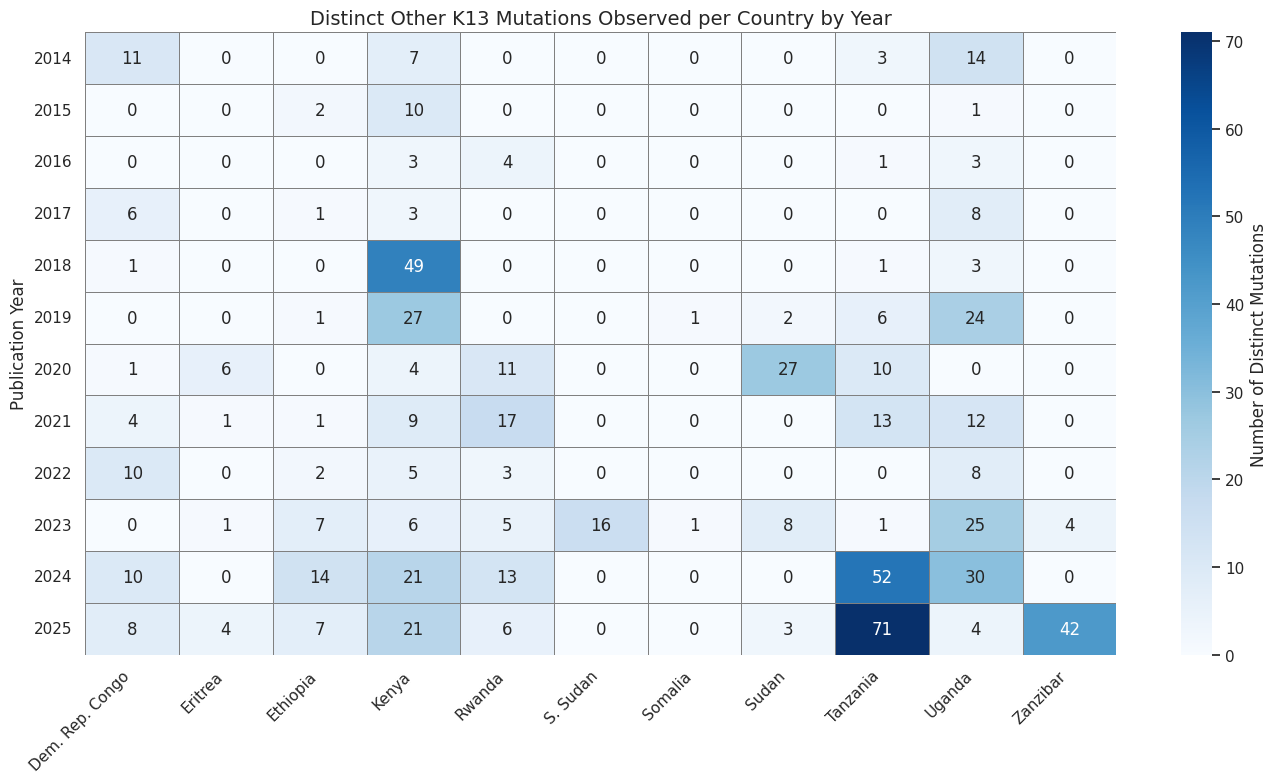

In [179]:

# Step 1: Filter rows with percentage_frequency > 0 and remove a specific PMID
df_filtered = nonvalidated_df1.copy()

# Step 2: Drop duplicates (mutation, country, year) to avoid overcounting
df_unique = df_filtered.drop_duplicates(subset=['country', 'other_k13_mutations', 'year_pub'])
# Step 3: Group by year and country, count unique other_k13_mutations
heatmap_data = (
    df_unique
    .groupby(['year_pub', 'country'])['other_k13_mutations']
    .nunique()
    .unstack(fill_value=0)  # Rows = years, Columns = countries
)

# Step 4: Plot the heatmap
plt.figure(figsize=(14, 8))
sns.set(font_scale=1.0)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    linecolor="gray",
    #cbar=False,
    cbar_kws={'label': 'Number of Distinct Mutations'}
)

plt.title("Distinct Other K13 Mutations Observed per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../distinct_other_k13_country.png", dpi=300, bbox_inches='tight')
plt.show()


In [180]:
nonvalidated_df1[(nonvalidated_df1["country"]=="Kenya") & (nonvalidated_df1["year_pub"]==2018)]["other_k13_mutations"].unique()

array(['S485K', 'N498I', 'L505F', 'W518C', 'R529K', 'N530K', 'V568G',
       'A578S', 'N587K', 'A676V', 'T677K', 'T677R', 'T677S', 'L678V',
       'A504G', 'E509G', 'N530Y', 'G592E', 'E596R', 'D584Y', 'N585K',
       'N609L', 'Y616N', 'E620K', 'R622G', 'S522R', 'N530I', 'N531I',
       'S536L', 'R539K', 'P570L', 'L598F', 'T677A', 'T474T', 'A569S', '-',
       'C469W', 'C469C', 'R513S', 'R597R', 'N490S', 'E507E', 'L457I',
       'G548G', 'I448M', 'S522C', 'A554S', 'I590F', 'E612D'], dtype=object)

In [181]:
df_unique[(df_unique["country"]=="Kenya") &(df_unique["year_pub"]==2014)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,samples_genotyped,where_sequenced,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
141,25180240,2014,2009-2012,Kenya,Western Kenya,Siaya,missing,missing,53,AL,...,53,missing,V520A,1.93,percentage,open,NaN,1.93,0.06116,34.28823
154,25180240,2014,2002-2004,Kenya,Western Kenya,Kisumu,missing,missing,50,AL,...,50,missing,C469C,1.24,percentage,open,NaN,1.24,-0.10221,34.76171
1396,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,T478T,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1397,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,E509E,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1398,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,A569T,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64
1399,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,A578S,3(2.78),raw counts,open,3.0,2.78,-0.069,34.64
1400,25367300,2014,2013-2014,Kenya,-,Kisumu,≥0.5,months,108,missing,...,108,Wellcome Trust Sanger Institute,Y630F,1(0.93),raw counts,open,1.0,0.93,-0.069,34.64


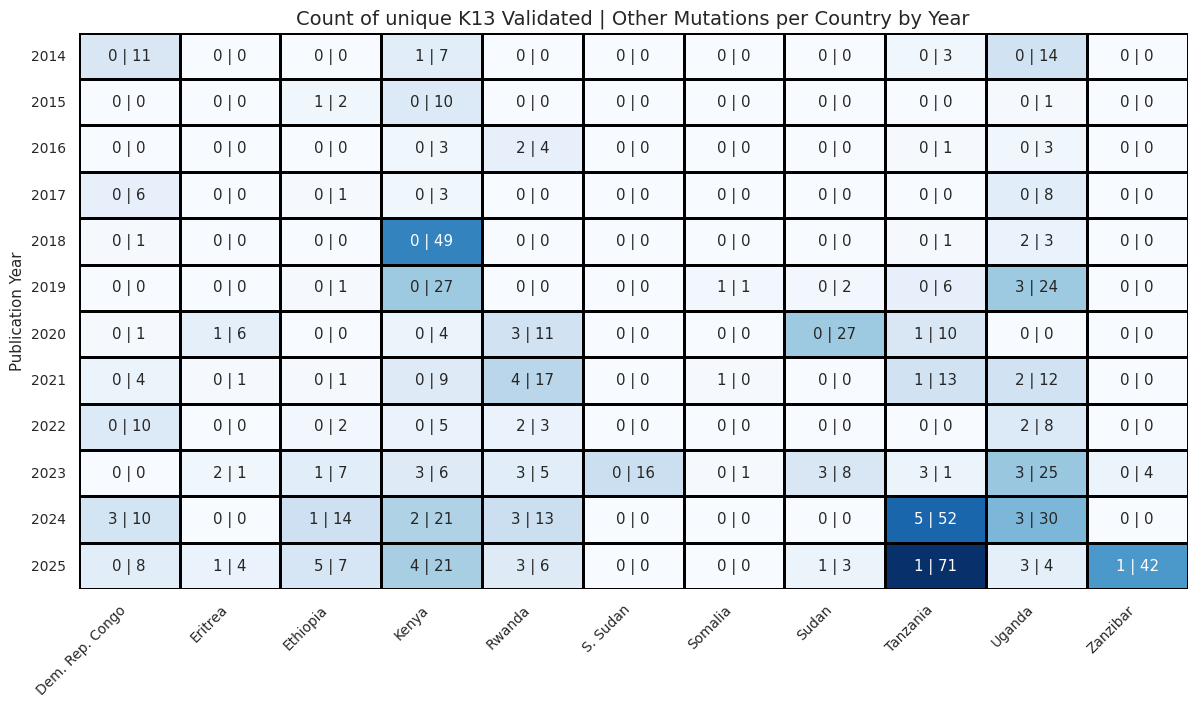

In [182]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ----------------------------
# Step 1: Preprocess validated data
# ----------------------------
val_df = validated_df1.copy()

# Keep only rows with meaningful frequency
val_df = val_df[val_df['percentage_frequency'] > 0]
val_df= val_df[val_df["k13_validated_mutations"] != "-"]
val_df = val_df.drop_duplicates(subset=['country', 'k13_validated_mutations', 'year_pub'])

validated_counts = (
    val_df.groupby(['year_pub', 'country'])['k13_validated_mutations']
    .nunique()
    .unstack(fill_value=0)
)

# ----------------------------
# Step 2: Preprocess non-validated data
# ----------------------------
nonval_df = nonvalidated_df1.copy()
#nonval_df = nonval_df[nonval_df['percentage_frequency'] > 0]
nonval_df = nonval_df.drop_duplicates(subset=['country', 'other_k13_mutations', 'year_pub'])

nonvalidated_counts = (
    nonval_df.groupby(['year_pub', 'country'])['other_k13_mutations']
    .nunique()
    .unstack(fill_value=0)
)

# ----------------------------
# Step 3: Align both tables and fill missing values
# ----------------------------
all_years = sorted(set(validated_counts.index) | set(nonvalidated_counts.index))
all_countries = sorted(set(validated_counts.columns) | set(nonvalidated_counts.columns))

validated_counts = validated_counts.reindex(index=all_years, columns=all_countries, fill_value=0)
nonvalidated_counts = nonvalidated_counts.reindex(index=all_years, columns=all_countries, fill_value=0)

# ----------------------------
# Step 4: Combine into single table as string
# ----------------------------
combined_table = validated_counts.astype(str) + " | " + nonvalidated_counts.astype(str)

# ----------------------------
# Step 5: Plot heatmap-like annotated table
# ----------------------------
plt.figure(figsize=(len(all_countries) * 1.1, len(all_years) * 0.6))
sns.set(font_scale=0.9)

ax = sns.heatmap(
    validated_counts + nonvalidated_counts,  # used only to generate color (can also be just 0s)
    annot=combined_table,
    fmt="",
    cmap="Blues",
    linewidths=0.73,
    linecolor="black",
    cbar=False  # Hide colorbar
)

plt.title("Count of unique K13 Validated | Other Mutations per Country by Year", fontsize=14)
plt.xlabel("")
plt.ylabel("Publication Year")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../results/k13_validated_vs_other_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [183]:
validated_df1[(validated_df1["country"]=="Tanzania")&(validated_df1["year_pub"]==2024) & (validated_df1['k13_validated_mutations']=="C469Y")]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
227,38746440,2024,2022-2023,Tanzania,Tanzania,Kibingo,missing,missing,1692,AL,...,non-synonymous,0.7,Brown University,I205T,none,open,1.939,0.7,-3.69906,30.65566
1227,39367758,2024,2022-2023,Tanzania,Northwest,missing,missing,missing,1692,AL,...,non-synonymous,0.1,Brown University,"P441, C469FL",percentage,open,1.692,0.1,-4.10000,32.13330


In [184]:
nonvalidated_df1[(nonvalidated_df1["country"]=="Rwanda")&(nonvalidated_df1["year_pub"]==2021)]["other_k13_mutations"].unique()

array(['C469F', 'G533A', 'V555A', 'A578S', 'M460I', 'V487I', 'A578V',
       'A626E', 'G592E+V637I', 'R513L', 'R575I', 'E605K', 'E651K',
       'P667R', 'P441L', 'G449A', 'R575K'], dtype=object)

In [185]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [186]:
df_unique[(df_unique["country"]=="Rwanda")&(df_unique["year_pub"]==2021)]["other_k13_mutations"].unique()

array(['C469F', 'G533A', 'V555A', 'A578S', 'M460I', 'V487I', 'A578V',
       'A626E', 'G592E+V637I', 'R513L', 'R575I', 'E605K', 'E651K',
       'P667R', 'P441L', 'G449A', 'R575K'], dtype=object)

In [187]:
df_filtered[df_filtered["country"]=="Kenya"]["other_k13_mutations"].unique()

array(['-', 'A578S', 'R255K', 'S182T', 'P96Q', 'V520A', 'C469C', 'S522C',
       'A569S', 'P553P', 'S477S', 'M442V', 'Y500Y', 'G538G', 'N554S',
       'C439C', 'N531N', 'V568I', 'I416V', 'H384Y', 'Y328F', 'L258M',
       'K189T', 'G533G', 'P655P', 'G690G', 'A582V', 'T535T', 'I646L',
       'V637V', 'H560H', 'E643E', 'P667S', 'F451Y', 'R539T', 'N458Y',
       'N431S', 'A671V', '"504, 510"', 'W611S', 'C469T', 'S485K', 'N498I',
       'L505F', 'W518C', 'R529K', 'N530K', 'V568G', 'N587K', 'A676V',
       'T677K', 'T677R', 'T677S', 'L678V', 'A504G', 'E509G', 'N530Y',
       'G592E', 'E596R', 'D584Y', 'N585K', 'N609L', 'Y616N', 'E620K',
       'R622G', 'S522R', 'N530I', 'N531I', 'S536L', 'R539K', 'P570L',
       'L598F', 'T677A', 'T474T', 'C469W', 'R513S', 'R597R', 'N490S',
       'E507E', 'L457I', 'G548G', 'I448M', 'A554S', 'I590F', 'E612D',
       'D399N', 'A486S', 'C542R', 'G665S',
       'I354V, A486S, V487A, S522C, A578S, A582V, S600A, I634L, V666L, A676S',
       'S549P', 'S38C', 'K108

In [188]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [189]:
validated_df1[validated_df1["country"]=="Somalia"]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
902,34279219,2021,2016-2017,Somalia,missing,missing,missing,missing,138,AL,...,non-synonymous,1/138,"Institut Pasteur, Paris",-,raw counts,open,1,0.72,NaN,NaN
936,31296223,2019,2016-2017,Somalia,"Middle Shabelle, Puntland","Jowhar, Bosaso",>0.5,years,339,"AL,DHA/PPQ",...,non-synonymous,1/139(0.7),Institut Pasteur (Cambodia),-,raw counts,open,1,0.7,11.28421,49.18158


In [190]:
# Fix country name mismatches manually (example)
ch= {
     '-' : None
}

# Standardize names
nonvalidated_df1['longitude'] = nonvalidated_df1['longitude'].replace(ch)
nonvalidated_df1['latitude'] = nonvalidated_df1['latitude'].replace(ch)

/tmp/ipykernel_14588/1268145553.py:74: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


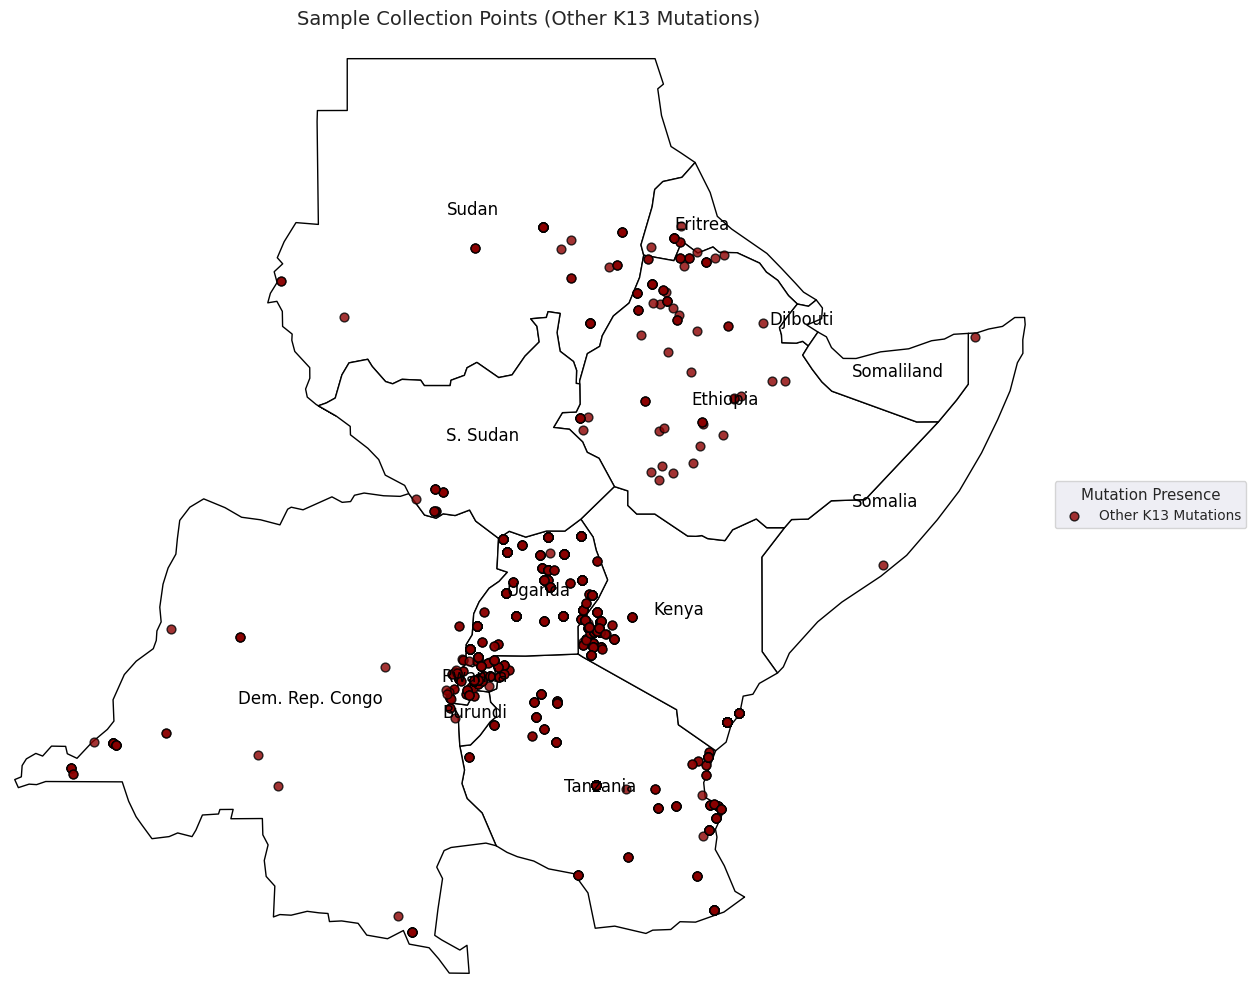

In [191]:
# ----------------------------
# SETUP: Define a single color for all mutations
# ----------------------------
mutation_color = 'darkred'  # Pick any color you prefer

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia', "Zanzibar"
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df = nonvalidated_df1.copy()
df['other_k13_mutations'] = df['other_k13_mutations'].str.strip().str.upper()
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO SPECIFIC COUNTRIES ONLY
# ----------------------------
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE POINTS GEO-DATAFRAME
# ----------------------------
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL JOIN: Keep only points inside selected countries
# ----------------------------
# Project both to Web Mercator
world_proj = world_filtered.to_crs(epsg=3857)
points_proj = points_gdf.to_crs(epsg=3857)

# Spatial join to keep points within selected African countries
points_proj = gpd.sjoin(points_proj, world_proj, how='inner', predicate='within')

# Reproject back for plotting
world_filtered = world_proj.to_crs(epsg=4326)
points_gdf = points_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue')     # Ocean color

# Plot filtered countries
world_filtered.plot(ax=ax, color='white', edgecolor='black')

# Plot sample points
ax.scatter(
    points_gdf['longitude'], points_gdf['latitude'],
    color=mutation_color, label='Other K13 Mutations',
    edgecolor='black', s=40, alpha=0.8
)

# ----------------------------
# LABEL ONLY COUNTRIES IN THE LIST
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    centroid = row['centroid']
    ax.annotate(
        row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(12, 52)
ax.set_ylim(-13.4, 23)
ax.set_aspect('equal', adjustable='box')
ax.axis("off")
ax.legend(title='Mutation Presence', bbox_to_anchor=(1, 0.5), loc='center left')
plt.title('Sample Collection Points (Other K13 Mutations)', fontsize=14)
plt.tight_layout()
plt.savefig("../results/other_k13_mutations_points_filtered_white.png", dpi=300, bbox_inches='tight')
plt.show()


In [192]:
unvaldf=(
    df.groupby(['country', 'other_k13_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)
unvaldf

,country,other_k13_mutations,percentage_frequency
0,Dem. Rep. Congo,-,NaN
1,Dem. Rep. Congo,522R,0.40
2,Dem. Rep. Congo,569S,0.40
3,Dem. Rep. Congo,581D,0.40
4,Dem. Rep. Congo,A557S,36.31
...,...,...,...
551,Zanzibar,T192P,1.55
552,Zanzibar,T573N,0.68
553,Zanzibar,V196I,1.00
554,Zanzibar,V637I,0.20


In [193]:
df["country"].unique()

array(['Uganda', 'Dem. Rep. Congo', 'Kenya', 'Ethiopia', 'Tanzania',
       'Sudan', 'Rwanda', 'Eritrea', 'Zanzibar', 'Somalia', 'S. Sudan'],
      dtype=object)

In [194]:
df[df["country"]=="South Sudan"]["latitude"].nunique()

0

In [195]:
unvaldf[unvaldf["country"]=="Zanzibar"]

,country,other_k13_mutations,percentage_frequency
510,Zanzibar,A212S,0.610000
511,Zanzibar,A481V,NaN
512,Zanzibar,A578S,1.136000
513,Zanzibar,E263Q,0.950000
514,Zanzibar,G220S,0.530000
515,Zanzibar,G3V,1.180000
516,Zanzibar,G538V,NaN
517,Zanzibar,H136N,2.416667
518,Zanzibar,I148L,0.690000
519,Zanzibar,I354V,0.620000


In [196]:
nonvalidated_df1[nonvalidated_df1["country"]=="DRC"]["pmid"].unique()

array([], dtype=object)

/tmp/ipykernel_14588/2577801452.py:123: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


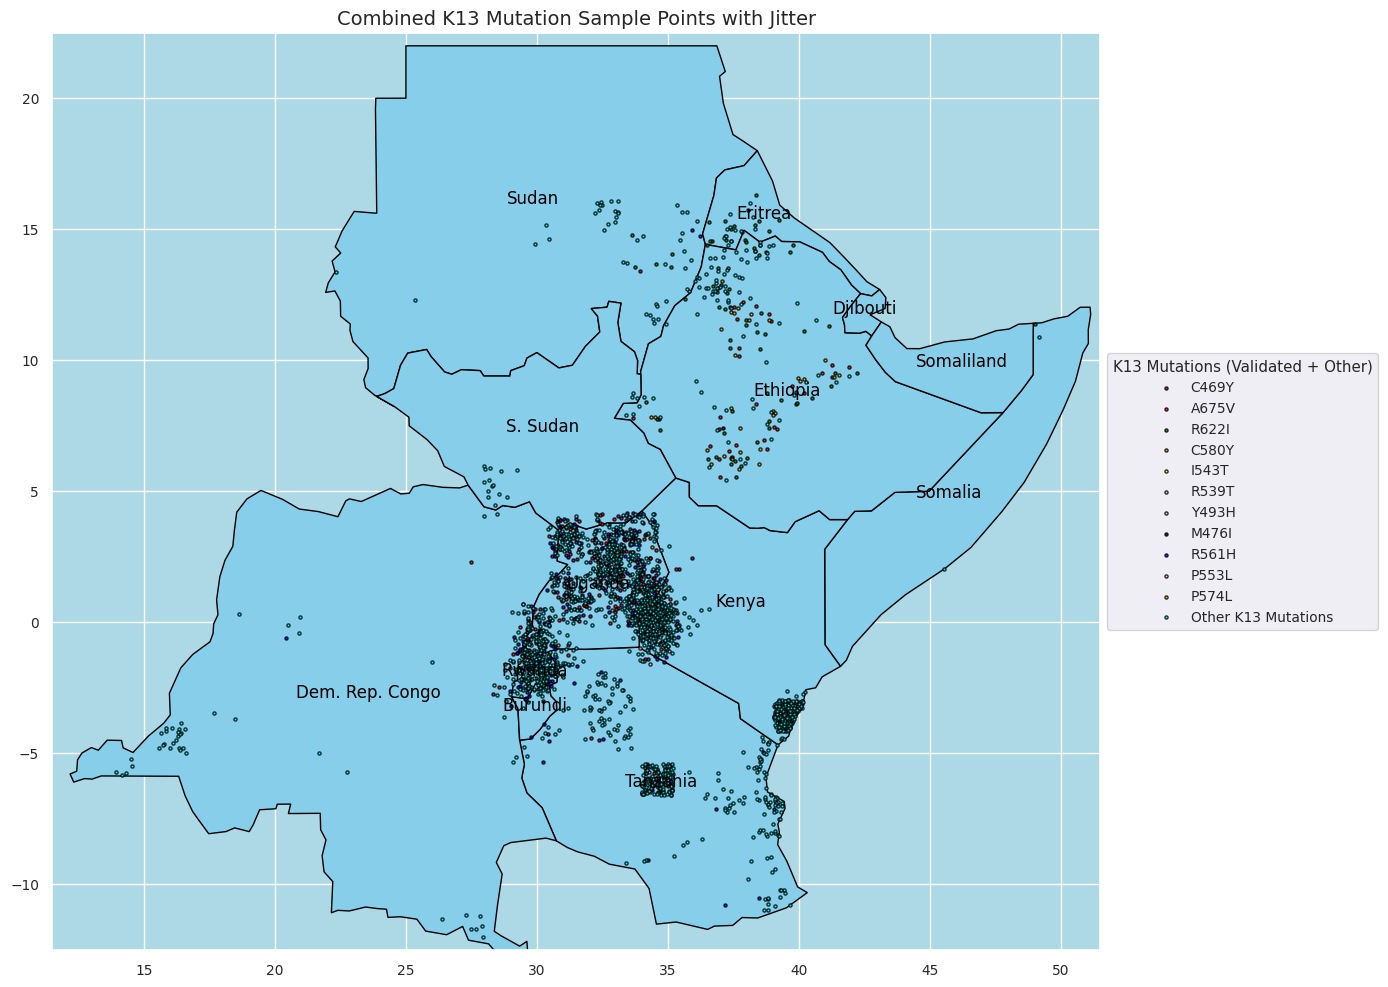

In [197]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
validated_colors = {
    'C469Y': 'purple',
    'A675V': 'red',
    'R622I': 'green',
    'C580Y': 'darkorange',
    'I543T': 'yellow',
    'R539T': 'palegreen',
    'Y493H': 'lightgrey',
    'M476I': 'black',
    'R561H': 'blue',
    'P553L': 'pink',
    'P574L': 'orange',
}
nonvalidated_color = 'cyan'

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN VALIDATED DATA
# ----------------------------
validated_df = validated_df1.copy()
validated_df['k13_validated_mutations'] = validated_df['k13_validated_mutations'].str.strip().str.upper()
validated_df = validated_df[validated_df['k13_validated_mutations'].isin(validated_colors.keys())]
validated_df = validated_df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# CLEAN NON-VALIDATED DATA
# ----------------------------
nonvalidated_df = nonvalidated_df1.copy()
nonvalidated_df['other_k13_mutations'] = nonvalidated_df['other_k13_mutations'].str.strip().str.upper()
nonvalidated_df = nonvalidated_df.dropna(subset=['latitude', 'longitude', 'other_k13_mutations'])

# ----------------------------
# APPLY JITTER TO LAT/LONG
# ----------------------------
def apply_jitter(df, lon_col='longitude', lat_col='latitude', jitter_strength=0.6):
    df = df.copy()
    df[lon_col] += np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
    df[lat_col] += np.random.uniform(-jitter_strength, jitter_strength, size=len(df))
    return df

validated_df = apply_jitter(validated_df, 'longitude', 'latitude', jitter_strength=0.6)
nonvalidated_df = apply_jitter(nonvalidated_df, 'longitude', 'latitude', jitter_strength=0.6)

# ----------------------------
# LOAD MAP SHAPEFILE & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE GEO-DATAFRAMES
# ----------------------------
gdf_validated = gpd.GeoDataFrame(
    validated_df,
    geometry=gpd.points_from_xy(validated_df['longitude'], validated_df['latitude']),
    crs='EPSG:4326'
)

gdf_nonvalidated = gpd.GeoDataFrame(
    nonvalidated_df,
    geometry=gpd.points_from_xy(nonvalidated_df['longitude'], nonvalidated_df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL FILTER: Keep only points within selected countries
# ----------------------------
world_proj = world_filtered.to_crs(epsg=3857)
gdf_validated_proj = gdf_validated.to_crs(epsg=3857)
gdf_nonvalidated_proj = gdf_nonvalidated.to_crs(epsg=3857)

gdf_validated_proj = gpd.sjoin(gdf_validated_proj, world_proj, how='inner', predicate='within')
gdf_nonvalidated_proj = gpd.sjoin(gdf_nonvalidated_proj, world_proj, how='inner', predicate='within')

# Reproject back
gdf_validated = gdf_validated_proj.to_crs(epsg=4326)
gdf_nonvalidated = gdf_nonvalidated_proj.to_crs(epsg=4326)
world_filtered = world_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot countries
world_filtered.plot(ax=ax, color='skyblue', edgecolor='black')

# Plot validated mutation points
for mutation, color in validated_colors.items():
    subset = gdf_validated[gdf_validated['k13_validated_mutations'] == mutation]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=5, alpha=0.8
    )

# Plot non-validated mutation points
ax.scatter(
    gdf_nonvalidated['longitude'], gdf_nonvalidated['latitude'],
    color=nonvalidated_color, label='Other K13 Mutations',
    edgecolor='black', s=5, alpha=0.8
)

# ----------------------------
# LABEL COUNTRIES
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    ax.annotate(
        row['NAME'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(11.5, 51.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

ax.legend(title='K13 Mutations (Validated + Other)', bbox_to_anchor=(1, 0.5), loc='center left')
plt.title('Combined K13 Mutation Sample Points with Jitter', fontsize=14)
plt.tight_layout()
plt.savefig("../results/combined_k13_mutations_with_jitter.png", dpi=300, bbox_inches='tight')
plt.show()


## the tanzania map

In [198]:
validated_df1["country"].unique()

array(['Uganda', 'Ethiopia', 'Dem. Rep. Congo', 'Tanzania', 'Kenya',
       'Rwanda', 'Zanzibar', 'Somalia', 'Eritrea', 'South Sudan', 'Sudan'],
      dtype=object)

In [199]:
tanzania_df= validated_df1[(validated_df1["country"]=="Tanzania") | (validated_df["country"]=="Zanzibar")]
tanzania_df

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
26,39159629,2024,2021,Tanzania,Dar es salaam,missing,>0.5,years,570,AL,...,non-synonymous,0,University of North Carolina,"R255K, L258M",raw counts,open,0,0,-6.0000,34.6000
27,39159629,2024,2021,Tanzania,Dar es salaam,missing,>0.5,years,570,AL,...,non-synonymous,0,University of North Carolina,-,raw counts,open,0,0,-6.0000,34.6000
28,39159629,2024,2021,Tanzania,Dar es salaam,missing,>0.5,years,570,AL,...,non-synonymous,0,University of North Carolina,-,raw counts,open,0,0,-6.0000,34.6000
29,39159629,2024,2021,Tanzania,Dodoma,missing,>0.5,years,594,AL,...,non-synonymous,0,University of North Carolina,"R255K, L258M, K189T",raw counts,open,0,0,-6.0000,34.6000
30,39159629,2024,2021,Tanzania,Dodoma,missing,>0.5,years,594,AL,...,non-synonymous,0,University of North Carolina,-,raw counts,open,0,0,-6.0000,34.6000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1203,40802860,2025,2022-2024,Zanzibar,missing,Kusini,all years,years,1433,-,...,non-synonymous,1/114,Brown University,"A578S, E263Q, K189T, L116I, L258M, N151S, R255...",raw count,open,1,0.88,-6.3379,39.4915
1227,39367758,2024,2022-2023,Tanzania,Northwest,missing,missing,missing,1692,AL,...,non-synonymous,0.1,Brown University,"P441, C469FL",percentage,open,1.692,0.1,-4.1000,32.1333
1228,39367758,2024,2022-2023,Tanzania,Northwest,missing,missing,missing,1692,AL,...,non-synonymous,12.1,Brown University,"P441, C469FL",percentage,open,204.732,12.1,-4.1000,32.1333
1229,39367758,2024,2022-2023,Tanzania,Northwest,missing,missing,missing,1692,AL,...,non-synonymous,0.3,Brown University,"P441, C469FL",percentage,open,5.076,0.3,-4.1000,32.1333


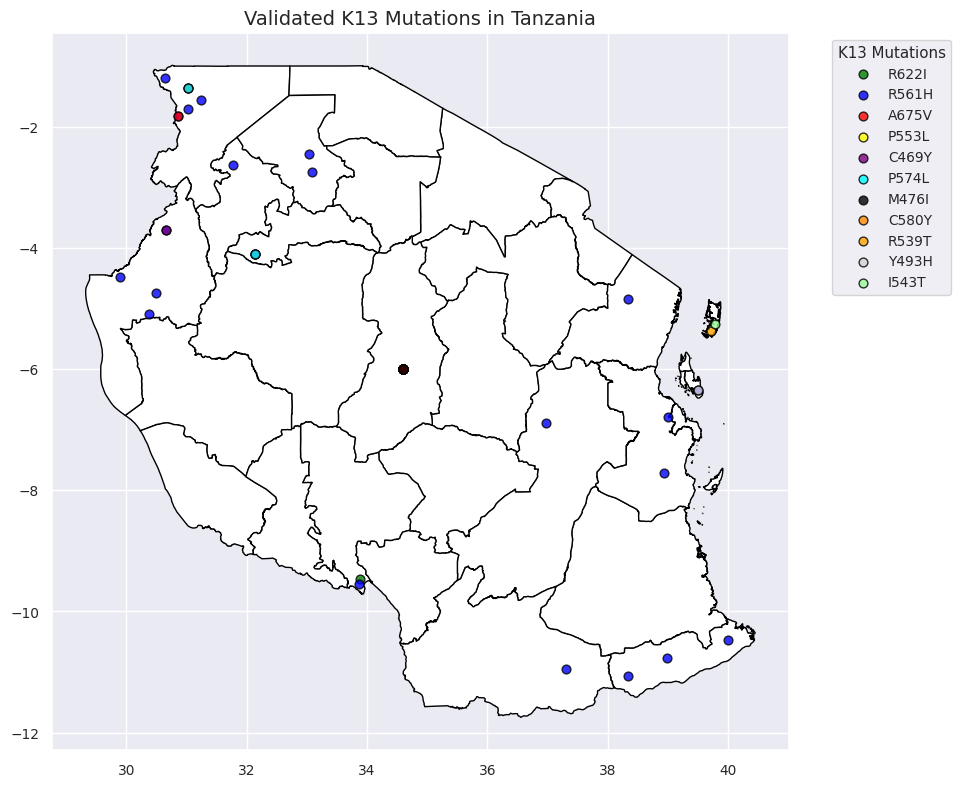

In [200]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
}

# ----------------------------
# CLEAN DATA
# ----------------------------
df = tanzania_df.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude', 'percentage_frequency'])

# ----------------------------
# LOAD TANZANIA MAP (Level 2)
# ----------------------------
tanzania_lvl2 = gpd.read_file("/home/kimani/Desktop/k13-review/data/gadm41_TZA_1.json")

# Ensure CRS is EPSG:4326
if tanzania_lvl2.crs != 'EPSG:4326':
    tanzania_lvl2 = tanzania_lvl2.to_crs('EPSG:4326')

# ----------------------------
# PLOT MAP + SAMPLE POINTS
# ----------------------------
fig, ax = plt.subplots(figsize=(10, 8))

# Plot the Tanzania Level 2 boundaries
tanzania_lvl2.plot(ax=ax, color="white", edgecolor="black")

# Plot each mutation’s sample points
for mutation, color in mutation_colors.items():
    subset = df[df['k13_validated_mutations'] == mutation]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_title("Validated K13 Mutations in Tanzania", fontsize=14)
ax.legend(title='K13 Mutations', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.axis("on")

plt.tight_layout()
plt.show()


In [201]:
validated_df1["longitude"].unique()

array([32.43001  , 34.00421  , 37.06321  , 38.23333  ,        nan,
       34.6      , 31.75     , 34.76171  , 31.16667  , 31.5      ,
       30.40766  , 29.3037   , 29.1059   , 30.10683  , 29.8764   ,
       28.97556  , 29.45022  , 29.7718   , 30.21195  , 29.3937   ,
       30.4572   , 30.04992  , 30.08467  , 29.58279  , 29.6305   ,
       30.50488  , 30.09107  , 30.2654   , 31.24633  , 30.85696  ,
       31.03132  , 30.65566  , 30.64709  , 30.8      , 29.23568  ,
       29.02427  , 29.18138  , 33.35336  , 32.83333  , 31.11     ,
       33.315    , 34.       , 29.98588  , 29.73     , 34.42     ,
       30.00777  , 34.04753  , 31.       , 32.74402  , 32.75057  ,
       34.08333  , 29.7474   , 29.88     , 38.93647  , 34.75229  ,
       41.86611  , 41.00892  , 34.76666  , 34.30085  , 31.02485  ,
       32.75     , 32.50071  , 30.0333   , 37.4668   , 36.83333  ,
       39.7739   , 39.718    , 39.4915   , 36.15637  , 36.21667  ,
       36.75     , 37.166666 , 34.26775  , 39.6833   , 39.1666

In [202]:
del(list)

/tmp/ipykernel_14588/4090661676.py:63: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/tmp/ipykernel_14588/4090661676.py:73: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
/tmp/ipykernel_14588/4090661676.py:108: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.985])


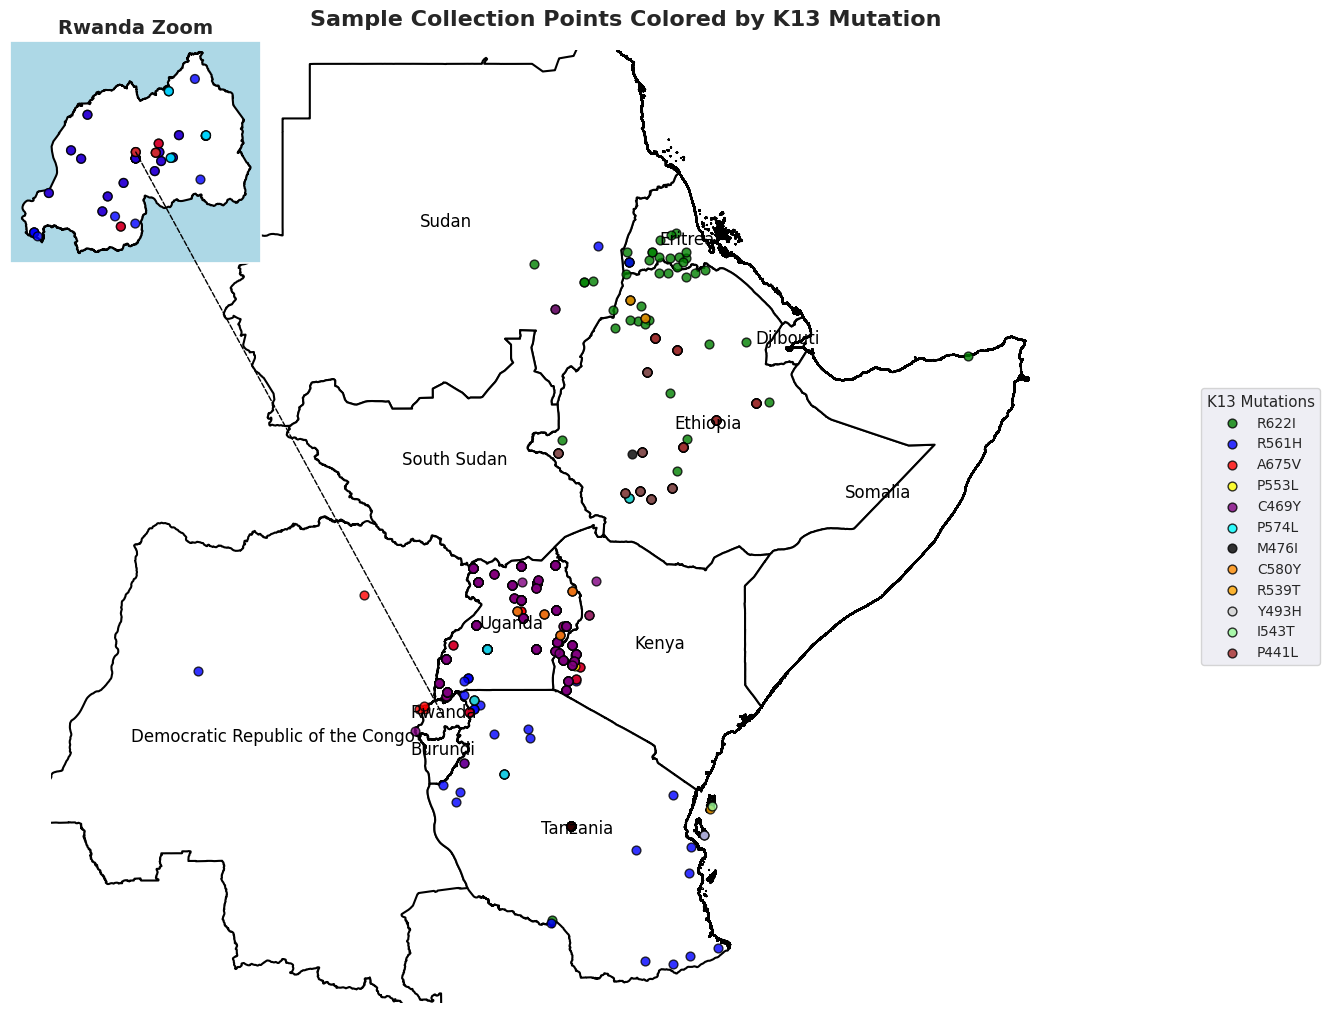

In [214]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch

# Load merged Level 0 shapefile
shp_path = "/home/kimani/Documents/EA_SHAPE_FILES/east_africa_level0_merged.shp"
world_africa = gpd.read_file(shp_path)

# List of countries to plot
african_countries = [
    'Tanzania', 'Rwanda', 'Kenya', 'Uganda', 'Sudan',
    'Democratic Republic of the Congo', 'Djibouti', 'Burundi',
    'Eritrea', 'Ethiopia', 'South Sudan', 'Somalia'
]

# Filter to selected countries using 'COUNTRY' column
world_africa = world_africa[world_africa['COUNTRY'].isin(african_countries)]
# Your mutation color dictionary (adjust or keep as needed)
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
    'P441L': 'brown'
}

# Assume your sample data DataFrame is named 'df' with columns:
# 'latitude', 'longitude', 'k13_validated_mutations', 'country'
# (Make sure 'country' matches the country names used here)

# Plot setup
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')
ax.set_facecolor('lightblue')

# Plot countries with bold borders
world_africa.plot(ax=ax, color='white', edgecolor='black', linewidth=1.5)

#clean data
df = validated_df1.copy()
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(mutation_colors.keys())]
df = df.dropna(subset=['latitude', 'longitude'])
#df= df.drop(subset='percentage')

# Plot sample points by mutation (excluding Rwanda)
for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

# Add country labels (using centroids)
world_africa['centroid'] = world_africa.geometry.centroid
for _, row in world_africa.iterrows():
    ax.annotate(
        row['COUNTRY'],
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center', fontsize=12, color='black'
    )

# Inset map for Rwanda zoom
rwanda_shape = world_africa[world_africa['COUNTRY'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]

ax_inset = inset_axes(ax, width="22%", height="30%", loc='upper left', borderpad=-3)
ax_inset.set_facecolor('lightblue')

rwanda_shape.plot(ax=ax_inset, color='white', edgecolor='black', linewidth=1.5)

rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)

ax_inset.set_title('Rwanda Zoom', fontsize=14, weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# Connect main map to inset
con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)

# Final adjustments
ax.set_xlim(15.5, 57.5)
ax.set_ylim(-12.5, 22.5)
ax.set_aspect('equal', adjustable='box')

ax.legend(title='K13 Mutations', bbox_to_anchor=(1, 0.5), loc='center left')
ax.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.985])
plt.suptitle('Sample Collection Points Colored by K13 Mutation', fontsize=16, weight='bold', y=1.01)
plt.savefig("../results/figures/white_validated_map.png", dpi=720, bbox_inches= 'tight')
plt.show()

/tmp/ipykernel_14588/3697623281.py:60: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid


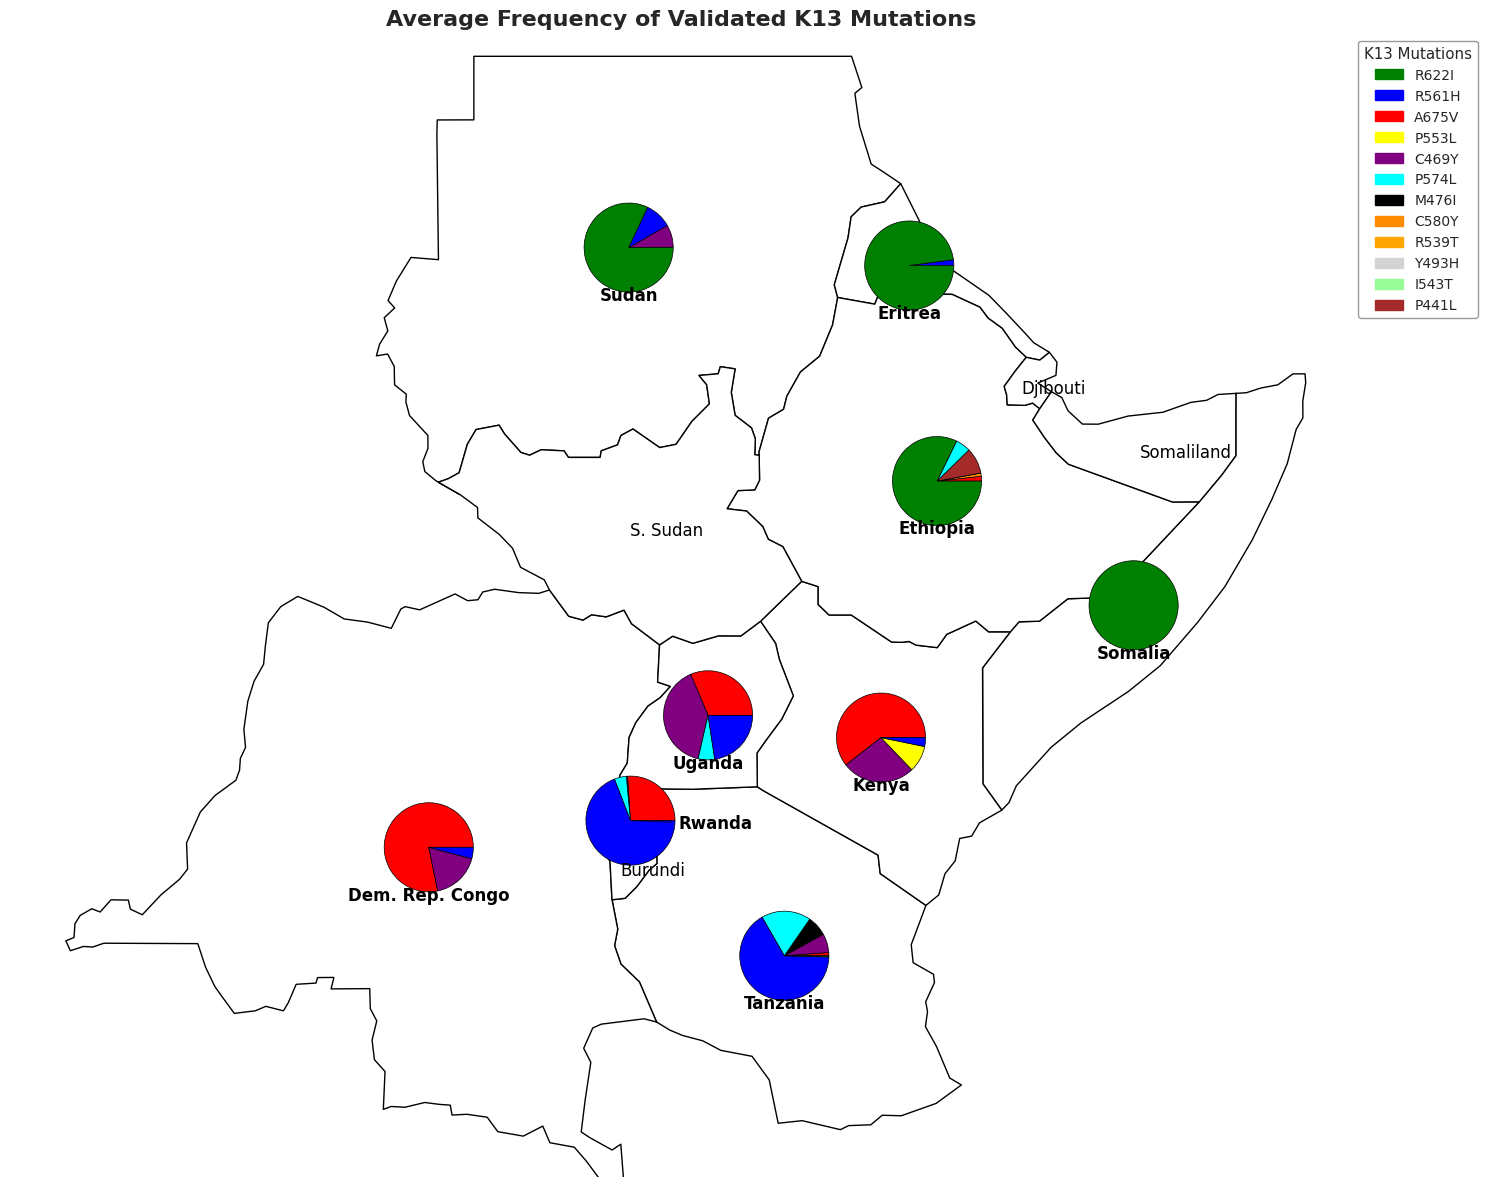

In [215]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------
mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
    'P441L': 'brown'
}

valid_mutations = list(mutation_colors.keys())

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia'
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df_clean = validated_df1[
    validated_df1['k13_validated_mutations'].isin(valid_mutations)
].dropna(subset=['longitude', 'latitude', 'percentage_frequency'])

# ----------------------------
# GROUP BY COUNTRY & MUTATION: average frequency
# ----------------------------
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# ----------------------------
# LOAD WORLD MAP & FILTER COUNTRIES
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# GET CENTROIDS FOR COUNTRY LABELING
# ----------------------------
world_centroids = world_filtered[['NAME', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
world_centroids = world_centroids.rename(columns={'NAME': 'country'})

# ----------------------------
# MERGE frequencies with centroid coords
# ----------------------------
coords = world_centroids[['country', 'latitude', 'longitude']]
plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------
def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# DRAW THE MAP AND PIES
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 12))
world_filtered.plot(ax=ax, color='white', edgecolor='black')
fig.patch.set_facecolor('white')  # Set figure background to white
ax.set_facecolor('lightblue') 

# Draw pie charts
for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]

    draw_proportional_pie(ax, lon, lat, muts, freqs, radius=1.4)

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_aspect('equal', adjustable='datalim')
ax.autoscale(enable=False)

# Centered on East/Central Africa
ax.set_xlim(20, 43)
ax.set_ylim(-12, 21.5)
ax.axis("off")
# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax.legend(handles=legend_handles, title='K13 Mutations',
                   loc='upper left', bbox_to_anchor=(1, 1),
                   borderaxespad=0.5, fontsize=10)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Annotate country names with specific styles
# Annotate country names with specific styles
exclude_countries = ['S. Sudan', 'Burundi', 'Somaliland', 'Djibouti']

for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']

    if country == 'Rwanda':
        # Side label with dashed leader line
        label_x = x + 1.5  # shift right
        label_y = y - 0.1  # slight vertical shift
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(label_x, label_y),
            textcoords="data",
            fontsize=12,
            color='black',
            ha='left',
            weight="bold",
            va='center',
            arrowprops=dict(
                arrowstyle='-',
                linestyle='dashed',
                color='black',
                lw=0.5
            )
        )
    elif country in exclude_countries:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(-7, -8),
            textcoords="offset points",
            fontsize=12,
            color='black'
        )
    else:
        ax.annotate(
            country,
            xy=(x, y),
            xytext=(0, -38),
            textcoords="offset points",
            ha='center',
            fontsize=12,
            color='black',
            weight='bold'
        )

plt.title('Average Frequency of Validated K13 Mutations', fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../results/validated_mutations_africa_plain.png", dpi=300, bbox_inches='tight')
plt.show()

In [216]:
print(df['country'].unique())


['Uganda' 'Ethiopia' 'Tanzania' 'Kenya' 'Rwanda' 'Dem. Rep. Congo'
 'Zanzibar' 'Somalia' 'Eritrea' 'Sudan']


In [217]:
print(world_africa['COUNTRY'].unique())


['Burundi' 'Democratic Republic of the Congo' 'Djibouti' 'Eritrea'
 'Ethiopia' 'Kenya' 'Rwanda' 'Sudan' 'Somalia' 'South Sudan' 'Tanzania'
 'Uganda']


/tmp/ipykernel_14588/1327966239.py:78: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid
/tmp/ipykernel_14588/1327966239.py:134: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/tmp/ipykernel_14588/1327966239.py:175: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]


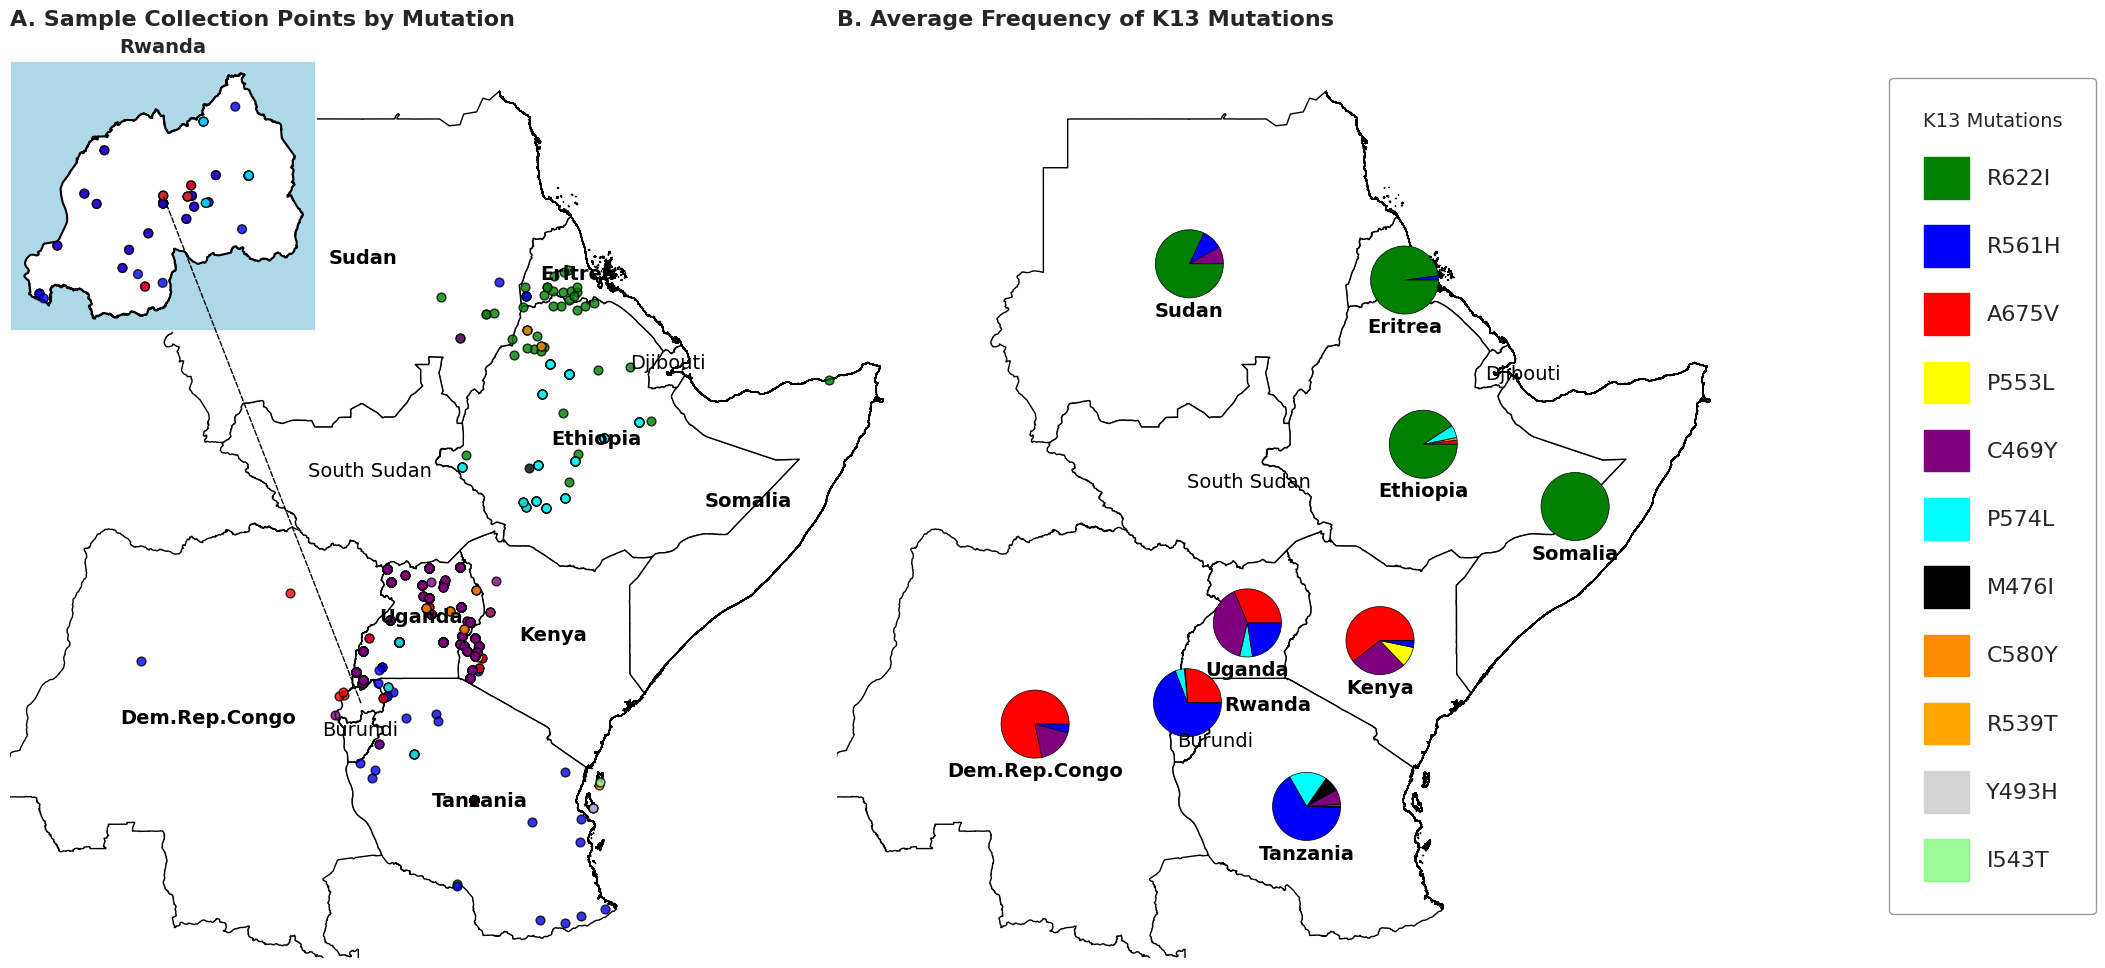

In [223]:
# ======================================================
# K13 MUTATION MAPS – Panels A & B (Single Shapefile)
# ======================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
import pandas as pd

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------

mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
    #'P441L': 'brown'
}
valid_mutations = list(mutation_colors.keys())

# ----------------------------
# LOAD AND PREPARE GEODATA
# ----------------------------

shp_path = "/home/kimani/Documents/EA_SHAPE_FILES/east_africa_level0_merged.shp"
world_africa = gpd.read_file(shp_path)

# Keep only the countries of interest
african_countries = [
    'Tanzania', 'Rwanda', 'Kenya', 'Uganda', 'Sudan',
    'Democratic Republic of the Congo', 'Djibouti', 'Burundi',
    'Eritrea', 'Ethiopia', 'South Sudan', 'Somalia'
]
world_africa = world_africa[world_africa['COUNTRY'].isin(african_countries)]

# Reproject for accurate centroids
world_africa = world_africa.to_crs(epsg=3395)
world_africa['centroid'] = world_africa.geometry.centroid
world_africa = world_africa.to_crs(epsg=4326)

# ----------------------------
# CLEAN DATA
# ----------------------------

df = validated_df1.copy()
#df = df[df["percentage_frequency"] != 0]
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(valid_mutations)]
df = df.dropna(subset=['latitude', 'longitude'])
df['country'] = df['country'].replace({
    'Dem. Rep. Congo': "Democratic Republic of the Congo"})

# ----------------------------
# PIE CHART DATA (Panel B)
# ----------------------------

df_clean = df.dropna(subset=['percentage_frequency'])
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# Compute centroid coordinates
world_centroids = world_africa[['GID_0', 'COUNTRY', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
coords = world_centroids[['COUNTRY', 'latitude', 'longitude']].rename(columns={'COUNTRY': 'country'})

plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------

def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# PLOT: SIDE BY SIDE PANELS A AND B
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
plt.subplots_adjust(wspace=-0.2)
fig.patch.set_facecolor('white')

shared_xlim = (15.5, 57.5)
shared_ylim = (-12.5, 25.5)

# ----------------------------
# PANEL A: Sample Collection Points
# ----------------------------

ax1 = axes[0]
ax1.set_facecolor('lightblue')
world_africa.plot(ax=ax1, color='white', edgecolor='black', linewidth=1)

for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax1.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

world_africa['centroid'] = world_africa.geometry.centroid

out = ["Djibouti", "South Sudan", "Burundi"]

for _, row in world_africa.iterrows():
    country_name = row['COUNTRY']

    if country_name == "Democratic Republic of the Congo":
        ax1.annotate(
            "Dem.Rep.Congo",
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=14,
            color='black',
            weight="bold"
        )
        continue  # ✅ Skip the next annotation to avoid duplicate labeling

    elif country_name == "Rwanda":
        continue  # ✅ Skip Rwanda (already shown in inset)
    elif country_name in out:
        ax1.annotate(
            country_name,
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=14,
            color='black'
        )
        continue  # ✅ Skip default bold label below

    # Default label for all other countries
    ax1.annotate(
        country_name,
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center',
        fontsize=14,
        color='black',
        weight="bold"
    )
# Rwanda inset
rwanda_shape = world_africa[world_africa['COUNTRY'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
ax_inset = inset_axes(ax1, width="30%", height="35%", loc='upper left', borderpad=0)
ax_inset.set_facecolor('lightblue')
rwanda_shape.plot(ax=ax_inset, color='white', edgecolor='black', linewidth=1.5)
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)
ax_inset.set_title('Rwanda', fontsize=14 , weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax1.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax1, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)

# Shared limits and layout
ax1.set_xlim(shared_xlim)
ax1.set_ylim(shared_ylim)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title("A. Sample Collection Points by Mutation", loc='left', fontsize=16, weight='bold')

# ----------------------------
# PANEL B: Pie Chart Map
# ----------------------------

ax2 = axes[1]
ax2.set_facecolor('lightblue')
world_africa.plot(ax=ax2, color='white', edgecolor='black')
ax2.set_aspect('equal')
ax2.axis("off")
ax2.set_xlim(shared_xlim)
ax2.set_ylim(shared_ylim)

for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]
    draw_proportional_pie(ax2, lon, lat, muts, freqs, radius=1.4)

# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax2.legend(
    handles=legend_handles,
    title='K13 Mutations',
    title_fontsize=14,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.5,
    fontsize=16,
    ncol=1,
    handleheight=2.5,
    labelspacing=1.2,
    borderpad=1.5
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Country labels
for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']
    
    if country == 'Rwanda':
        ax2.annotate(
            country, xy=(x, y),
            xytext=(x + 1.5, y - 0.1),
            textcoords="data",
            fontsize=14, color='black', ha='left', weight= "bold",
            va='center',
            arrowprops=dict(arrowstyle='-', linestyle='dashed', color='black', lw=0.5)
        )
    elif country == "Democratic Republic of the Congo":
        ax2.annotate(
            "Dem.Rep.Congo",
            xy=(x, y), xytext=(0, -38), textcoords="offset points",
            ha='center', fontsize=14, color='black', weight='bold'
        )
        
    elif country in ['South Sudan', 'Burundi', 'Djibouti']:
        ax2.annotate(
            country, xy=(x, y),
            xytext=(-7, -8), textcoords="offset points",
            fontsize=14, color='black'
        )
    else:
        ax2.annotate(
            country, xy=(x, y),
            xytext=(0, -38), textcoords="offset points",
            ha='center', fontsize=14, color='black', weight='bold'
        )

ax2.set_title("B. Average Frequency of K13 Mutations", loc='left', fontsize=16, weight='bold')

# ----------------------------
# SAVE AND SHOW
# ----------------------------

plt.savefig("../results/final/k13_combined_map_same_shape1.png", dpi=720, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14588/3800342397.py:78: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_centroids['centroid'] = world_centroids['geometry'].centroid
/tmp/ipykernel_14588/3800342397.py:134: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_africa['centroid'] = world_africa.geometry.centroid
/tmp/ipykernel_14588/3800342397.py:175: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]


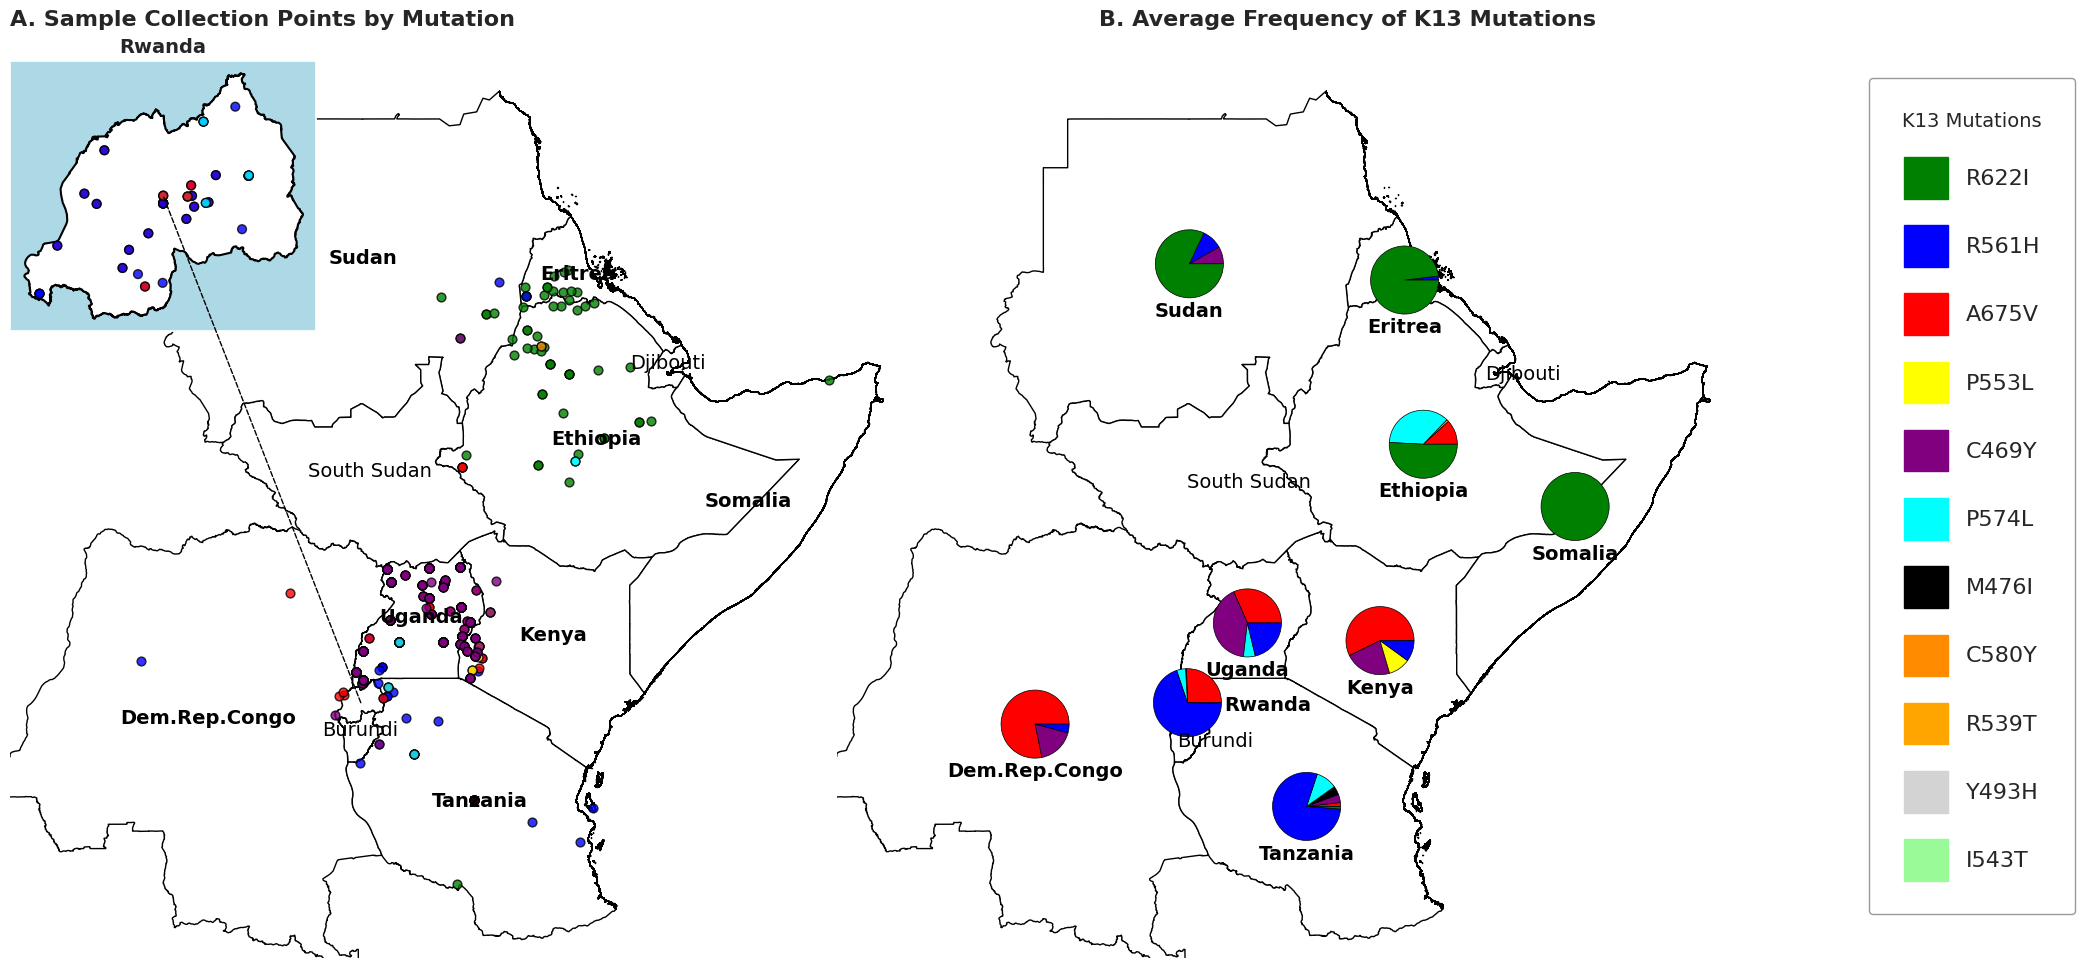

In [224]:
# ======================================================
# K13 MUTATION MAPS – Panels A & B (Single Shapefile)
# ======================================================

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
import matplotlib.patches as mpatches
import pandas as pd

# ----------------------------
# SETUP MUTATION COLORS
# ----------------------------

mutation_colors = {
    'R622I': 'green',
    'R561H': 'blue',
    'A675V': 'red',
    'P553L': 'yellow',
    'C469Y': 'purple',
    'P574L': 'cyan',
    'M476I': 'black',
    'C580Y': 'darkorange',
    'R539T': 'orange',
    'Y493H': 'lightgrey',
    'I543T': 'palegreen',
    #'P441L': 'brown'
}
valid_mutations = list(mutation_colors.keys())

# ----------------------------
# LOAD AND PREPARE GEODATA
# ----------------------------

shp_path = "/home/kimani/Documents/EA_SHAPE_FILES/east_africa_level0_merged.shp"
world_africa = gpd.read_file(shp_path)

# Keep only the countries of interest
african_countries = [
    'Tanzania', 'Rwanda', 'Kenya', 'Uganda', 'Sudan',
    'Democratic Republic of the Congo', 'Djibouti', 'Burundi',
    'Eritrea', 'Ethiopia', 'South Sudan', 'Somalia'
]
world_africa = world_africa[world_africa['COUNTRY'].isin(african_countries)]

# Reproject for accurate centroids
world_africa = world_africa.to_crs(epsg=3395)
world_africa['centroid'] = world_africa.geometry.centroid
world_africa = world_africa.to_crs(epsg=4326)

# ----------------------------
# CLEAN DATA
# ----------------------------

df = validated_df1.copy()
df = df[df["percentage_frequency"] != 0]
df['k13_validated_mutations'] = df['k13_validated_mutations'].str.strip().str.upper()
df = df[df['k13_validated_mutations'].isin(valid_mutations)]
df = df.dropna(subset=['latitude', 'longitude'])
df['country'] = df['country'].replace({
    'Dem. Rep. Congo': "Democratic Republic of the Congo"})

# ----------------------------
# PIE CHART DATA (Panel B)
# ----------------------------

df_clean = df.dropna(subset=['percentage_frequency'])
freq_per_mutation_country = (
    df_clean.groupby(['country', 'k13_validated_mutations'])['percentage_frequency']
    .mean()
    .reset_index()
)

# Compute centroid coordinates
world_centroids = world_africa[['GID_0', 'COUNTRY', 'geometry']].copy()
world_centroids['centroid'] = world_centroids['geometry'].centroid
world_centroids['longitude'] = world_centroids['centroid'].x
world_centroids['latitude'] = world_centroids['centroid'].y
coords = world_centroids[['COUNTRY', 'latitude', 'longitude']].rename(columns={'COUNTRY': 'country'})

plot_data = freq_per_mutation_country.merge(coords, on='country', how='inner')

# ----------------------------
# FUNCTION TO DRAW PROPORTIONAL PIES
# ----------------------------

def draw_proportional_pie(ax, x, y, mutations, frequencies, radius=1):
    total = sum(frequencies)
    if total == 0:
        return
    start_angle = 0
    for mut, freq in zip(mutations, frequencies):
        angle = 360 * (freq / total)
        wedge = Wedge(
            center=(x, y),
            r=radius,
            theta1=start_angle,
            theta2=start_angle + angle,
            facecolor=mutation_colors.get(mut, 'gray'),
            edgecolor='black',
            lw=0.5
        )
        ax.add_patch(wedge)
        start_angle += angle

# ----------------------------
# PLOT: SIDE BY SIDE PANELS A AND B
# ----------------------------

fig, axes = plt.subplots(1, 2, figsize=(24, 12))
plt.subplots_adjust(wspace=-0.2)
fig.patch.set_facecolor('white')

shared_xlim = (15.5, 57.5)
shared_ylim = (-12.5, 25.5)

# ----------------------------
# PANEL A: Sample Collection Points
# ----------------------------

ax1 = axes[0]
ax1.set_facecolor('lightblue')
world_africa.plot(ax=ax1, color='white', edgecolor='black', linewidth=1)

for mutation, color in mutation_colors.items():
    subset = df[(df['k13_validated_mutations'] == mutation) & (df['country'] != 'Rwanda')]
    ax1.scatter(
        subset['longitude'], subset['latitude'],
        color=color, label=mutation, edgecolor='black', s=40, alpha=0.8
    )

world_africa['centroid'] = world_africa.geometry.centroid

out = ["Djibouti", "South Sudan", "Burundi"]

for _, row in world_africa.iterrows():
    country_name = row['COUNTRY']

    if country_name == "Democratic Republic of the Congo":
        ax1.annotate(
            "Dem.Rep.Congo",
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=14,
            color='black',
            weight="bold"
        )
        continue  # ✅ Skip the next annotation to avoid duplicate labeling

    elif country_name == "Rwanda":
        continue  # ✅ Skip Rwanda (already shown in inset)
    elif country_name in out:
        ax1.annotate(
            country_name,
            xy=(row['centroid'].x, row['centroid'].y),
            ha='center',
            fontsize=14,
            color='black'
        )
        continue  # ✅ Skip default bold label below

    # Default label for all other countries
    ax1.annotate(
        country_name,
        xy=(row['centroid'].x, row['centroid'].y),
        ha='center',
        fontsize=14,
        color='black',
        weight="bold"
    )
# Rwanda inset
rwanda_shape = world_africa[world_africa['COUNTRY'] == 'Rwanda']
rwanda_centroid = rwanda_shape.geometry.centroid.iloc[0]
ax_inset = inset_axes(ax1, width="30%", height="35%", loc='upper left', borderpad=0)
ax_inset.set_facecolor('lightblue')
rwanda_shape.plot(ax=ax_inset, color='white', edgecolor='black', linewidth=1.5)
rwanda_points = df[df['country'] == 'Rwanda']
ax_inset.scatter(
    rwanda_points['longitude'], rwanda_points['latitude'],
    color=[mutation_colors[mut] for mut in rwanda_points['k13_validated_mutations']],
    edgecolor='black', s=40, alpha=0.8
)
ax_inset.set_title('Rwanda', fontsize=14 , weight="bold")
ax_inset.set_xticks([])
ax_inset.set_yticks([])

con = ConnectionPatch(
    xyA=(rwanda_centroid.x, rwanda_centroid.y), coordsA=ax1.transData,
    xyB=(0.5, 0.5), coordsB=ax_inset.transAxes,
    axesA=ax1, axesB=ax_inset,
    color="black", linestyle="--", linewidth=1
)
fig.add_artist(con)

# Shared limits and layout
ax1.set_xlim(shared_xlim)
ax1.set_ylim(shared_ylim)
ax1.set_aspect('equal')
ax1.axis('off')
ax1.set_title("A. Sample Collection Points by Mutation", loc='left', fontsize=16, weight='bold')

# ----------------------------
# PANEL B: Pie Chart Map
# ----------------------------

ax2 = axes[1]
ax2.set_facecolor('lightblue')
world_africa.plot(ax=ax2, color='white', edgecolor='black')
ax2.set_aspect('equal')
ax2.axis("off")
ax2.set_xlim(shared_xlim)
ax2.set_ylim(shared_ylim)

for country in plot_data['country'].unique():
    country_data = plot_data[plot_data['country'] == country]
    muts = country_data['k13_validated_mutations'].tolist()
    freqs = country_data['percentage_frequency'].tolist()
    lat = country_data['latitude'].iloc[0]
    lon = country_data['longitude'].iloc[0]
    draw_proportional_pie(ax2, lon, lat, muts, freqs, radius=1.4)

# Legend
legend_handles = [mpatches.Patch(color=color, label=mut) for mut, color in mutation_colors.items()]
legend = ax2.legend(
    handles=legend_handles,
    title='K13 Mutations',
    title_fontsize=14,
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    borderaxespad=0.5,
    fontsize=16,
    ncol=1,              # number of columns (try 2 to make it shorter & wider)
    handleheight=2.5,    # increases the vertical spacing
    labelspacing=1.2,    # increases spacing between entries
    borderpad=1.5,       # adds more padding inside the legend box
)

legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('gray')

# Country labels
for _, row in coords.iterrows():
    country = row['country']
    x, y = row['longitude'], row['latitude']
    
    if country == 'Rwanda':
        ax2.annotate(
            country, xy=(x, y),
            xytext=(x + 1.5, y - 0.1),
            textcoords="data",
            fontsize=14, color='black', ha='left', weight= "bold",
            va='center',
            arrowprops=dict(arrowstyle='-', linestyle='dashed', color='black', lw=0.5)
        )
    elif country == "Democratic Republic of the Congo":
        ax2.annotate(
            "Dem.Rep.Congo",
            xy=(x, y), xytext=(0, -38), textcoords="offset points",
            ha='center', fontsize=14, color='black', weight='bold'
        )
        
    elif country in ['South Sudan', 'Burundi', 'Djibouti']:
        ax2.annotate(
            country, xy=(x, y),
            xytext=(-7, -8), textcoords="offset points",
            fontsize=14, color='black'
        )
    else:
        ax2.annotate(
            country, xy=(x, y),
            xytext=(0, -38), textcoords="offset points",
            ha='center', fontsize=14, color='black', weight='bold'
        )

ax2.set_title("B. Average Frequency of K13 Mutations", loc='center', fontsize=16, weight='bold')

# ----------------------------
# SAVE AND SHOW
# ----------------------------

plt.savefig("../results/final/k13_combined_map_same_shape.png", dpi=720, bbox_inches='tight')
plt.show()


In [220]:
validated_df1["k13_validated_mutations"].unique()

array(['C469Y', 'A675V', 'R622I', 'C580Y', 'I543T', 'R539T', 'Y493H',
       'M476I', 'R561H', 'P553L', 'P574L', '-\t', 0, 'P441L'],
      dtype=object)

In [221]:
validated_df1[validated_df1["country"]=="Ethiopia"]["k13_validated_mutations"].unique()

array(['R622I', 'M476I', 'P574L', 'A675V', 'C580Y', 'P441L'], dtype=object)

In [222]:
df[df["country"]=="Ethiopia"]["k13_validated_mutations"].unique()

array(['R622I', 'A675V', 'P574L', 'C580Y', 'P441L'], dtype=object)

In [211]:
validated_df1[(validated_df1["country"]=="Ethiopia") & (validated_df1["k13_validated_mutations"]=='P441L')]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
1254,40681807,2025,2019,Ethiopia,SNNP,Lante,>1,years,95,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,6.25100,36.58150
1258,40681807,2025,2019,Ethiopia,Oromia,Metehara,>1,years,93,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,8.90251,39.91814
1262,40681807,2025,2020,Ethiopia,SNNP,Shile,>1,years,89,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,6.30000,37.11667
1266,40681807,2025,2022,Ethiopia,Gambela,Abol,>1,years,120,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,7.70477,34.10085
1270,40681807,2025,2022,Ethiopia,Amhara,Andasa,>1,years,119,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,11.50000,38.50000
1274,40681807,2025,2022,Ethiopia,Oromia,Asendabo,>1,years,29,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,7.75666,37.22222
1278,40681807,2025,2022,Ethiopia,Oromia,Batu,>1,years,23,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,7.93580,38.71650
1282,40681807,2025,2022,Ethiopia,SNNP,Dilla,>1,years,10,missing,...,non-synonymous,10,Brown University,-,percentage,open,12,10,6.41000,38.31030
1286,40681807,2025,2022,Ethiopia,Somali,Erer,>1,years,31,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,9.55725,41.38540
1290,40681807,2025,2022,Ethiopia,Amhara,Jiga,>1,years,102,missing,...,non-synonymous,0,Brown University,-,percentage,open,0,0,10.67666,37.37731


In [117]:
validated_df1[validated_df1["country"]=="Kenya"]["k13_validated_mutations"].unique()

array(['P553L', 'A675V', 'R561H', 'R539T', 'C469Y', 0], dtype=object)

In [118]:
df[df["country"]=="Kenya"]["k13_validated_mutations"].unique()

array(['P553L', 'A675V', 'R561H', 'C469Y'], dtype=object)

In [119]:
validated_df1[(validated_df1["country"]=="Ethiopia")&(validated_df1["k13_validated_mutations"]== 'P574L') & (validated_df1["percentage_frequency"] != 0)]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
1022,10.1038/s43856-025-01008-0,2025,2019-2023,Ethiopia,Oromia,Batu,>1,Years,40,-,...,Non-Synonymous,17.2,Brown University,Present,percentage,open,4.988,17.2,7.9358,38.7165
1279,40681807,2025,2022,Ethiopia,Oromia,Batu,>1,years,23,missing,...,non-synonymous,10,Brown University,-,percentage,open,12,10,7.9358,38.7165


In [120]:
validated_df1[validated_df1['k13_validated_mutations']==0]

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,type_of_mutation,mutation_frequency_(%),where_sequenced,other_k13_mutations,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude
1005,40739505,2025,2022-2023,Kenya,Busia,Matayos,missing,missing,94,-,...,-,0,missing,A578S,none,open,NaN,0,0.36493,34.16494
1006,40739505,2025,2022-2024,Kenya,Busia,Sio Port,missing,missing,24,-,...,-,0,missing,-,none,open,NaN,0,0.22410,34.02163


In [121]:
nonvalidated_df1.columns

Index(['pmid', 'year_pub', 'year_sample', 'country', 'region/province', 'town',
       'participants_age', 'participants_age_unit', 'sample_size',
       'first_line_act', 'genotyping_assay', 'study_population',
       'samples_genotyped', 'where_sequenced', 'other_k13_mutations',
       'Frequency', 'data_extraction_comments', 'journal_access', 'raw_count',
       'percentage_frequency', 'latitude', 'longitude'],
      dtype='object')

In [122]:
candidate_markers = [
    "E252Q", "P441L", "C469F", "N537I", "G538V", "V568G"
]

potential_markers = [
    "P413A", "F495L", "R515K", "M579I", "D584V",
    "P527H", "G625R",
    "K438N", "G449A", "T508N", "Y511H", "S577L",
    "A582V", "N585K", "Q613E",
    "R100K", "E107V", "G50E"
]

In [123]:
nonvalidated_df1["other_k13_mutations"]= nonvalidated_df1["other_k13_mutations"].replace({"-": None})

In [124]:
def classify_mutation(mutation):
    if mutation in candidate_markers:
        return "Candidate"
    elif mutation in potential_markers:
        return "Potential"
    else:
        return "Non-validated"

nonvalidated_df1["mutation_status"] = nonvalidated_df1["other_k13_mutations"].apply(classify_mutation)
nonvalidated_df1

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,where_sequenced,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,mutation_status
0,34551228,2021,2015,Uganda,Northern Uganda,Gulu,≥0.5,years,77,AL,...,missing,C532S,2 (2.6),raw counts,open,2.0,2.6,2.85604,32.43001,Non-validated
1,34551228,2021,2015,Uganda,Northern Uganda,Gulu,≥0.5,years,77,AL,...,missing,V661I,1 (1.3),raw counts,open,1.0,1.3,2.85604,32.43001,Non-validated
2,34551228,2021,2016,Uganda,Northern Uganda,Gulu,≥0.5,years,94,AL,...,missing,G595C,1 (1.1),raw counts,open,1.0,1.1,2.85604,32.43001,Non-validated
3,34551228,2021,2018,Uganda,Northern Uganda,Gulu,≥0.5,years,67,AL,...,missing,A578S,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,Non-validated
4,34551228,2021,2018,Uganda,Northern Uganda,Gulu,≥0.5,years,67,AL,...,missing,S695T,1 (1.5),raw counts,open,1.0,1.5,2.85604,32.43001,Non-validated
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,40021306,2025,2021-2023,Dem. Rep. Congo,Kinshasa,"Binza, Maluku",All,years,6795,missing,...,Wellcome Sanger Institute,I634L,1(0.1),raw count,open,1.0,0.1,-4.46139,16.07861,Non-validated
2012,40021306,2025,2021-2023,Dem. Rep. Congo,Kinshasa,"Binza, Maluku",All,years,6795,missing,...,Wellcome Sanger Institute,D641N,1(0.1),raw count,open,1.0,0.1,-4.46139,16.07861,Non-validated
2013,38377612,2024,2022,Dem. Rep. Congo,South Kivu,Uvira,missing,missing,292,AL/ASAQ,...,missing,569S,1(0.4),raw count,closed,1.0,0.4,-3.4056,29.1376,Non-validated
2014,38377612,2024,2022,Dem. Rep. Congo,South Kivu,Miti Murhesa,missing,missing,292,AL/ASAQ,...,missing,581D,1(0.4),raw count,closed,1.0,0.4,-2.35558,28.7937,Non-validated


In [125]:
def create_summary(df, status_label):
    subset = df[
        (df["mutation_status"] == status_label) &
        (df["other_k13_mutations"].notna())
    ]
    
    summary = (
        subset.groupby("country")
        .agg(
            unique_mutation_count=("other_k13_mutations", "nunique"),
            mutations=("other_k13_mutations", lambda x: ", ".join(sorted(x.unique())))
        )
        .reset_index()
    )
    
    return summary

In [126]:
candidate_table = create_summary(nonvalidated_df1, "Candidate")
potential_table = create_summary(nonvalidated_df1, "Potential")
non_validated_table = create_summary(nonvalidated_df1, "Non-validated")

In [127]:
candidate_table.to_excel('../results/candidate_markers.xlsx', index=False)

In [128]:
potential_table.to_excel('../results/potential_markers.xlsx', index=False)

In [129]:
non_validated_table.to_excel('../results/non-validated_markers.xlsx', index=False)

In [130]:
nonvalidated_df1[nonvalidated_df1["country"]=='Somalia']

,pmid,year_pub,year_sample,country,region/province,town,participants_age,participants_age_unit,sample_size,first_line_act,...,where_sequenced,other_k13_mutations,Frequency,data_extraction_comments,journal_access,raw_count,percentage_frequency,latitude,longitude,mutation_status
1135,37170467,2023,2018,Somalia,Southern Somalia,"Afgoi , Balad",all ages,years,150,"AL,DHA/PPQ",...,"Bioneer (Republic of Korea), Chulabhorn Intern...",None,-,none,open,NaN,NaN,2.48779,45.6592,Non-validated
1136,31296223,2019,2016-2017,Somalia,"Middle Shabelle, Puntland","Jowhar, Bosaso",>0.5,years,339,"AL,DHA/PPQ",...,Institut Pasteur (Cambodia),None,-,none,open,NaN,NaN,11.28421,49.18158,Non-validated


/tmp/ipykernel_14588/3899636724.py:94: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


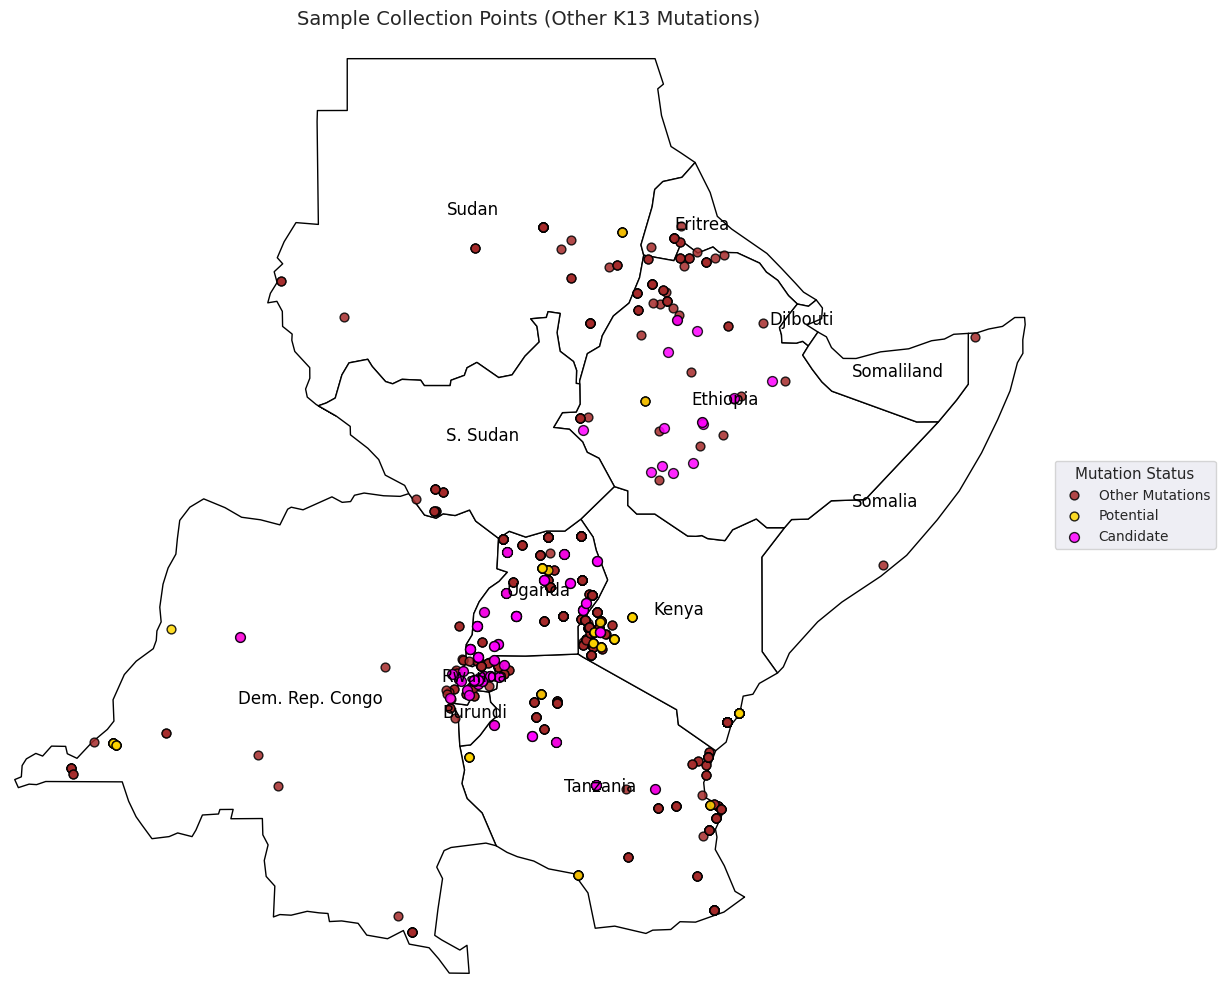

In [131]:
# ----------------------------
# SETUP: COLORS BASED ON MUTATION STATUS
# ----------------------------
status_colors = {
    "Candidate": "magenta",
    "Potential": "gold",
    "Non-validated": "brown"
}

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia', "Zanzibar"
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df = nonvalidated_df1.copy()
df['other_k13_mutations'] = df['other_k13_mutations'].str.strip().str.upper()
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO SPECIFIC COUNTRIES ONLY
# ----------------------------
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE POINTS GEO-DATAFRAME
# ----------------------------
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL JOIN: Keep only points inside selected countries
# ----------------------------
# Project both to Web Mercator
world_proj = world_filtered.to_crs(epsg=3857)
points_proj = points_gdf.to_crs(epsg=3857)

# Spatial join to keep points within selected African countries
points_proj = gpd.sjoin(points_proj, world_proj, how='inner', predicate='within')

# Reproject back for plotting
world_filtered = world_proj.to_crs(epsg=4326)
points_gdf = points_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Figure background
ax.set_facecolor('lightblue')     # Ocean color

# Plot filtered countries
world_filtered.plot(ax=ax, color='white', edgecolor='black')

# ----------------------------
# PLOT POINTS BY MUTATION STATUS
# ----------------------------
plot_order = ["Non-validated", "Potential", "Candidate"]  # Candidate on top
for status in plot_order:
    subset = points_gdf[points_gdf["mutation_status"] == status]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=status_colors[status],
        label=status,
        edgecolor='black',
        s=50 if status == "Candidate" else 40,
        alpha=0.85
    )

# Fix duplicate labels and rename "Non-validated" to "Other Mutations" in the legend
handles, labels = ax.get_legend_handles_labels()
new_labels = [lbl if lbl != "Non-validated" else "Other Mutations" for lbl in labels]
by_label = dict(zip(new_labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title='Mutation Status',
          bbox_to_anchor=(1, 0.5), loc='center left')

# ----------------------------
# LABEL ONLY COUNTRIES IN THE LIST
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    centroid = row['centroid']
    ax.annotate(
        row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(12, 52)
ax.set_ylim(-13.4, 23)
ax.set_aspect('equal', adjustable='box')
ax.axis("off")
plt.title('Sample Collection Points (Other K13 Mutations)', fontsize=14)
plt.tight_layout()
plt.savefig("../results/other_k13_mutations_points_filtered_white1.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_14588/3096548302.py:93: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  world_filtered['centroid'] = world_filtered.geometry.centroid


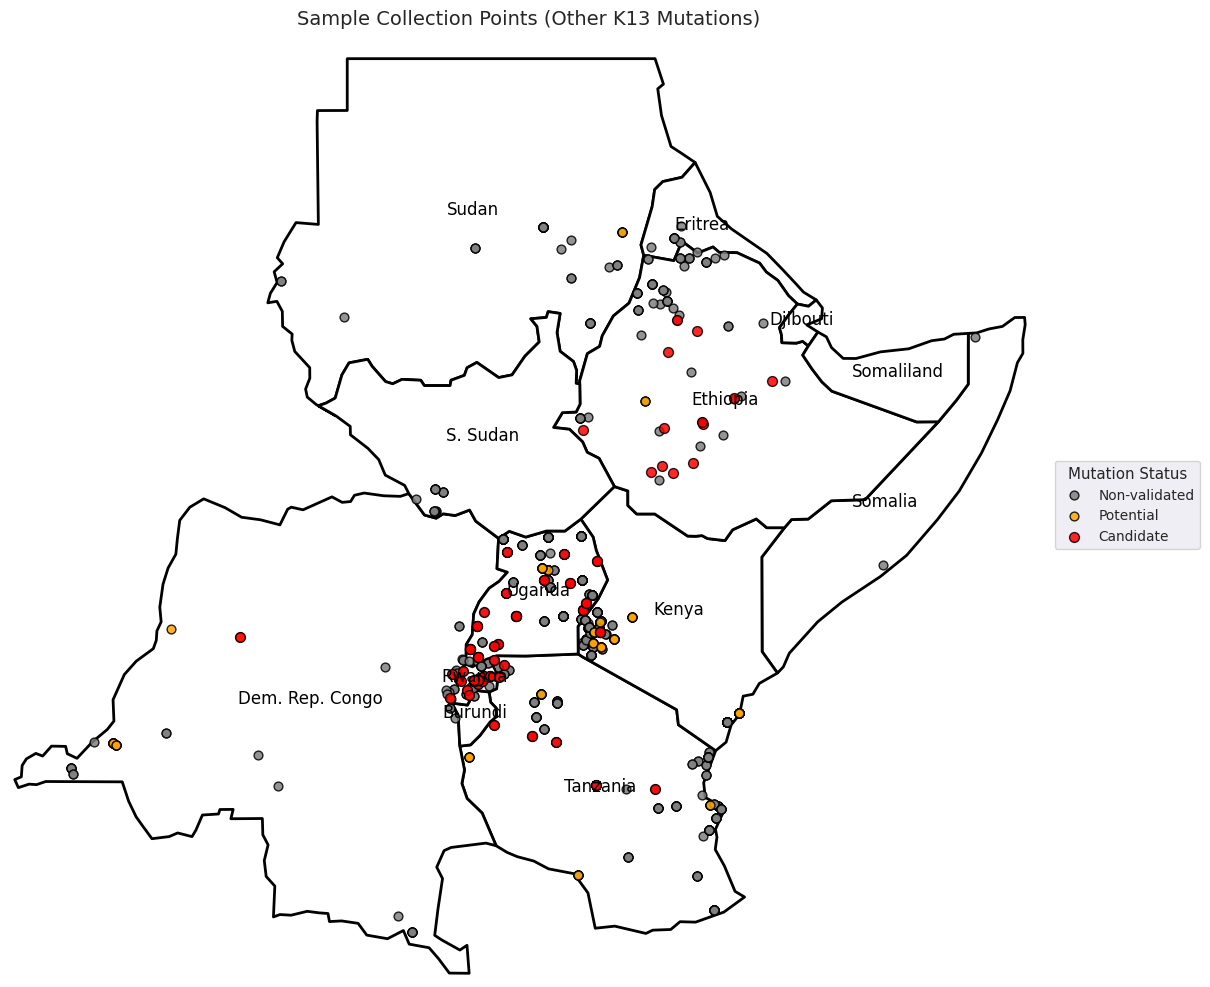

In [132]:
# ----------------------------
# SETUP: COLORS BASED ON MUTATION STATUS
# ----------------------------
status_colors = {
    "Candidate": "red",
    "Potential": "orange",
    "Non-validated": "gray"
}

# ----------------------------
# CUSTOM LIST OF AFRICAN COUNTRIES (DO NOT CHANGE)
# ----------------------------
african_countries = [
    'Kenya', 'Uganda', 'Tanzania', 'Sudan', 'S. Sudan', 'Ethiopia', 'Rwanda', 'Dem. Rep. Congo',
    'Burundi', 'Djibouti', 'Eritrea', 'Somaliland', 'Somalia', "Zanzibar"
]

# ----------------------------
# CLEAN DATA
# ----------------------------
df = nonvalidated_df1.copy()
df['other_k13_mutations'] = df['other_k13_mutations'].str.strip().str.upper()
df = df.dropna(subset=['latitude', 'longitude'])

# ----------------------------
# LOAD MAP SHAPEFILE
# ----------------------------
world = gpd.read_file('../ne_110m_admin_0_map_units/ne_110m_admin_0_map_units.shp')

# ----------------------------
# FILTER TO SPECIFIC COUNTRIES ONLY
# ----------------------------
world_filtered = world[world['NAME'].isin(african_countries)]

# ----------------------------
# CREATE POINTS GEO-DATAFRAME
# ----------------------------
points_gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
    crs='EPSG:4326'
)

# ----------------------------
# SPATIAL JOIN: Keep only points inside selected countries
# ----------------------------
# Project both to Web Mercator
world_proj = world_filtered.to_crs(epsg=3857)
points_proj = points_gdf.to_crs(epsg=3857)

# Spatial join to keep points within selected African countries
points_proj = gpd.sjoin(points_proj, world_proj, how='inner', predicate='within')

# Reproject back for plotting
world_filtered = world_proj.to_crs(epsg=4326)
points_gdf = points_proj.to_crs(epsg=4326)

# ----------------------------
# PLOT MAP
# ----------------------------
fig, ax = plt.subplots(figsize=(15, 10))
fig.patch.set_facecolor('white')  # Figure background
ax.set_facecolor('lightblue')     # Ocean color

# Plot filtered countries
world_filtered.plot(ax=ax, color='white', edgecolor='black', linewidth=2)

# ----------------------------
# PLOT POINTS BY MUTATION STATUS WITH BLACK BORDERS
# ----------------------------
plot_order = ["Non-validated", "Potential", "Candidate"]  # Candidate on top
for status in plot_order:
    subset = points_gdf[points_gdf["mutation_status"] == status]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=status_colors[status],
        edgecolor='black',   # BLACK borders 
        label=status,
        s=50 if status == "Candidate" else 40,
        alpha=0.85
    )

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(),
          title='Mutation Status',
          bbox_to_anchor=(1, 0.5), loc='center left')

# ----------------------------
# LABEL ONLY COUNTRIES IN THE LIST
# ----------------------------
world_filtered['centroid'] = world_filtered.geometry.centroid
for _, row in world_filtered.iterrows():
    centroid = row['centroid']
    ax.annotate(
        row['NAME'],
        xy=(centroid.x, centroid.y),
        ha='center', fontsize=12, color='black'
    )

# ----------------------------
# FINAL TOUCHES
# ----------------------------
ax.set_xlim(12, 52)
ax.set_ylim(-13.4, 23)
ax.set_aspect('equal', adjustable='box')
ax.axis("off")
plt.title('Sample Collection Points (Other K13 Mutations)', fontsize=14)
plt.tight_layout()
plt.savefig("../results/other_k13_mutations_points_filtered_white2.png", dpi=300, bbox_inches='tight')
plt.show()